In [154]:
# Importing core Python libraries for data handling, numerical computation, visualization, and warnings.
import sys
import os
import warnings
warnings.filterwarnings(action='ignore')

# Importing scientific computing, finance, and statistical modeling libraries.
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import yfinance as yf
import statsmodels

# Importing ARIMA-related tools for time-series modelling and forecasting.
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Importing custom project modules for forecasting, clustering, dataset preparation, optimization, and deep learning.
from src.myarima import MyARIMA
from src.init_dataset import InitDataset
from src.mykmeans import MyKMeans
import src.utils as utils
from src.mptoptimizer import MPTOptimizer
from src.dbscan import MyDBSCAN
from src.myLSTM import MyLSTM

print("Finished importing utils!")


Finished importing utils!


In [155]:
# Preparing dataset by loading pre-existing economic and stock data (no regeneration since init=False).
# These functions assemble economic indicators, merge stock datasets, and compute adjusted close prices.
InitDataset.create_econ_data(init=False)
InitDataset.create_merged_stock_data(init=False)
InitDataset.create_adj_closed_price(init=False)


In [156]:
# Loading historical stock price data for AAPL from CSV and converting the 'Date' column into a proper datetime index.
# This prepares the dataset for time-series analysis and visualization.
dateparse = lambda dates: pd.to_datetime(dates, format='%Y-%m-%d')
stock_market_data = pd.read_csv(r'dataset/stock_data/AAPL_data.csv', parse_dates=['Date'], index_col='Date', date_parser=dateparse)
stock_market_data.head()


,Open,High,Low,Close,Adj Close,Volume,ticker
Date,,,,,,,
2018-01-02,42.540001,43.075001,42.314999,43.064999,40.670986,102223600,AAPL
2018-01-03,43.132500,43.637501,42.990002,43.057499,40.663898,118071600,AAPL
2018-01-04,43.134998,43.367500,43.020000,43.257500,40.852768,89738400,AAPL
2018-01-05,43.360001,43.842499,43.262501,43.750000,41.317894,94640000,AAPL
2018-01-08,43.587502,43.902500,43.482498,43.587502,41.164425,82271200,AAPL


In [157]:
# Inspecting the dataset by checking its dimensions and verifying the time range covered by the stock data.
# This helps confirm data completeness and understand the total duration available for analysis.
print(stock_market_data.shape)

print(stock_market_data.index.min())
print(stock_market_data.index.max())

duration = stock_market_data.index.max() - stock_market_data.index.min()
print(duration)


(1509, 7)
2018-01-02 00:00:00
2023-12-29 00:00:00
2187 days 00:00:00


In [158]:
# Performing basic data cleaning checks to ensure dataset integrity.
# This includes identifying missing values, duplicate rows, and reviewing summary statistics.
print(stock_market_data.isnull().sum(), '\n')
print(stock_market_data.duplicated().sum())
print(stock_market_data.describe())


Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
ticker       0
dtype: int64 

0
              Open         High          Low        Close    Adj Close  \
count  1509.000000  1509.000000  1509.000000  1509.000000  1509.000000   
mean    110.326080   111.583562   109.157902   110.428236   108.703985   
std      51.003328    51.520038    50.513390    51.043671    51.349589   
min      35.994999    36.430000    35.500000    35.547501    34.075390   
25%      54.105000    54.794998    53.290001    53.872501    51.655396   
50%     123.660004   124.980003   122.139999   123.540001   121.447418   
75%     152.570007   154.559998   150.800003   152.740005   151.446182   
max     198.020004   199.619995   197.000000   198.110001   197.857529   

             Volume  
count  1.509000e+03  
mean   1.073273e+08  
std    5.513331e+07  
min    2.404830e+07  
25%    7.078370e+07  
50%    9.296430e+07  
75%    1.280440e+08  
max    4.265100e+08  


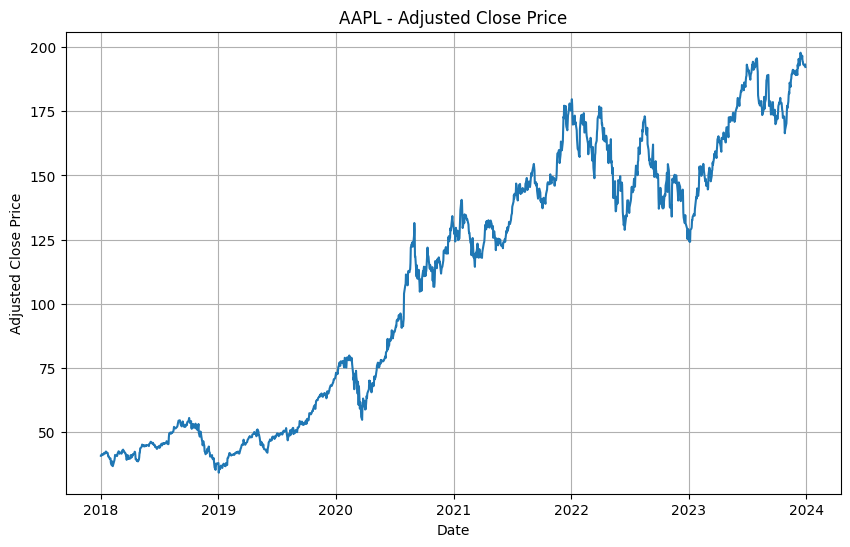

In [159]:
# Visualizing the historical trend of AAPL's adjusted closing price over time.
# This plot helps identify long-term patterns, volatility, and major price movements.
plt.figure(figsize=(10,6))
plt.grid(True)
plt.title('AAPL - Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.plot(stock_market_data['Adj Close'])
plt.show()


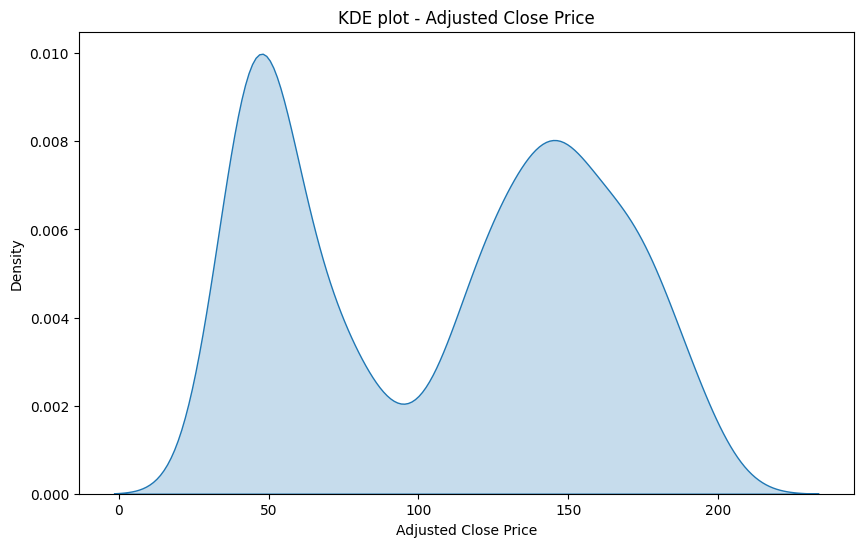

In [160]:
# Plotting the Kernel Density Estimate (KDE) to visualize the distribution of AAPL’s adjusted closing prices.
# This helps understand the underlying price density, skewness, and concentration of values.
plt.figure(figsize=(10,6))
sns.kdeplot(stock_market_data['Adj Close'], shade=True)
plt.title('KDE plot - Adjusted Close Price')
plt.xlabel('Adjusted Close Price')
plt.ylabel('Density')
plt.show()


In [161]:
test_df, train_df, index_data = InitDataset.get_test_train_data()

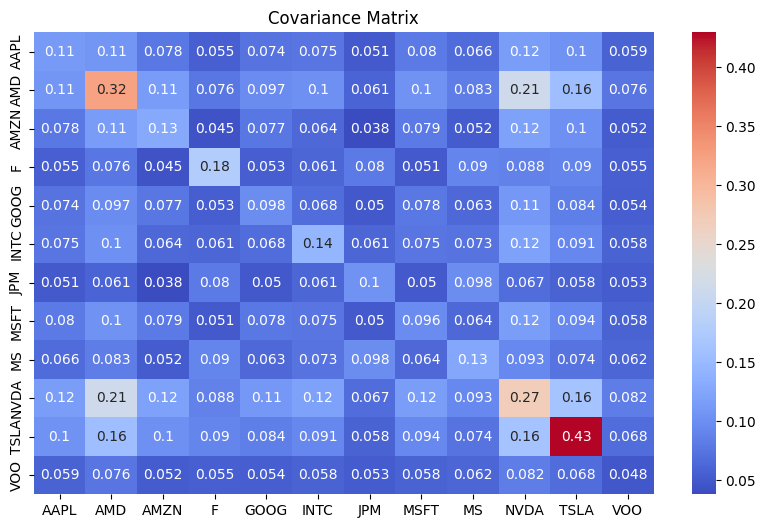

In [164]:
# Computing the annualized covariance matrix of portfolio returns and visualizing it using a heatmap.
# This helps identify how strongly different assets move together, revealing diversification potential and risk relationships.
ptf_returns = train_df.pct_change()
covariance = ptf_returns.cov() * 252

plt.figure(figsize=(10,6))
sns.heatmap(covariance, annot=True, cmap='coolwarm')
plt.title('Covariance Matrix')
plt.show()


In [165]:
# Calculating portfolio variance using equal weights across all assets.
# This computes overall risk by applying the quadratic form: wᵀΣw, where Σ is the covariance matrix.
weights = [0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25]
ptf_variance = np.transpose(weights) @ covariance @ weights
print(f'Portfolio Variance: {ptf_variance}')


Portfolio Variance: 0.7940522612656677


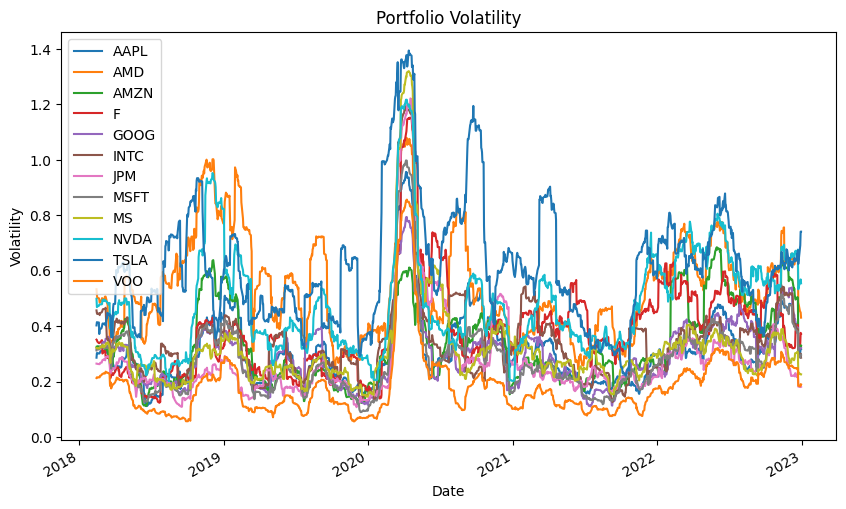

In [166]:
# Computing and visualizing the rolling 30-day annualized volatility of the portfolio.
# This shows how portfolio risk evolves over time by tracking fluctuations in return variability.
window = ptf_returns.rolling(30)
volatility = window.std() * np.sqrt(252)
volatility.plot(figsize=(10,6))
plt.title('Portfolio Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()


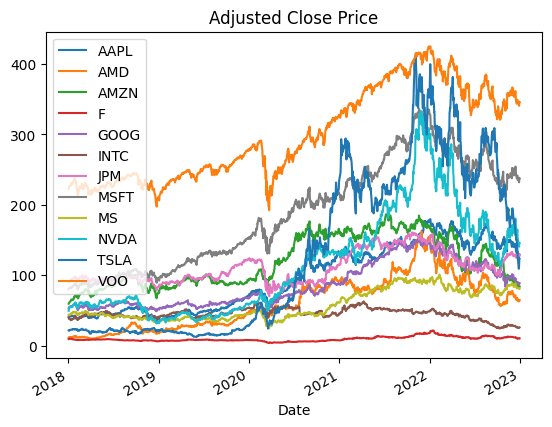

In [130]:
train_df.plot(title='Close Price - Adjusted')
plt.show()

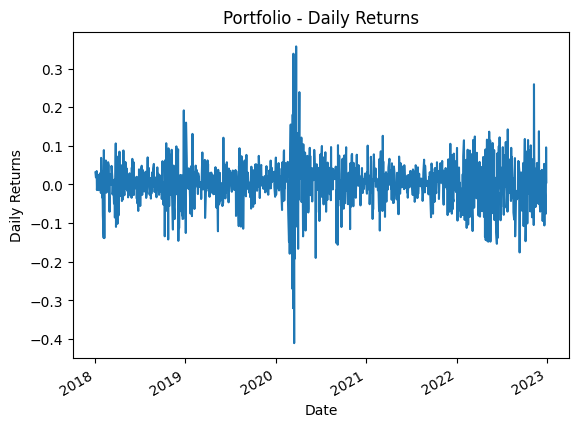

In [167]:
# Computing daily portfolio returns using weighted asset returns and visualizing their movement over time.
# This plot helps assess short-term performance fluctuations and overall return behavior of the portfolio.
asset_returns = train_df.pct_change()
ptf_returns = asset_returns @ weights

ptf_returns.plot().set_ylabel('Daily Returns')
plt.title('Portfolio - Daily Returns')
plt.show()


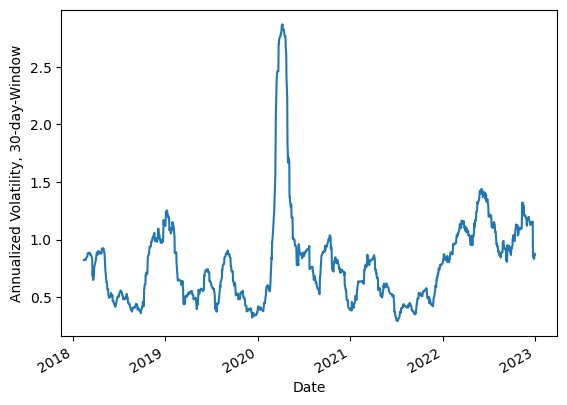

In [168]:
# Computing the 30-day rolling annualized volatility of the portfolio to analyze short-term risk dynamics.
# This helps identify periods of heightened or reduced volatility by smoothing daily fluctuations.
returns_window = ptf_returns.rolling(30)

volatility_series = returns_window.std() * np.sqrt(252)

volatility_series.plot().set_ylabel("Annualized Volatility, 30-day-Window")
plt.show()


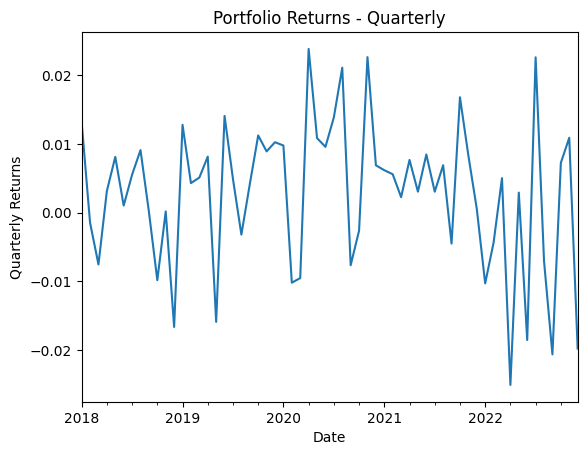

In [169]:
# Resampling daily portfolio returns into monthly-start (MS) periods to compute average quarterly-like returns.
# This transformation helps analyze medium-term performance trends by smoothing daily noise.
quarterly_returns = ptf_returns.resample('MS').mean().dropna()
quarterly_returns.plot().set_ylabel("Quarterly Returns")
plt.title('Portfolio Returns - Quarterly')
plt.show()


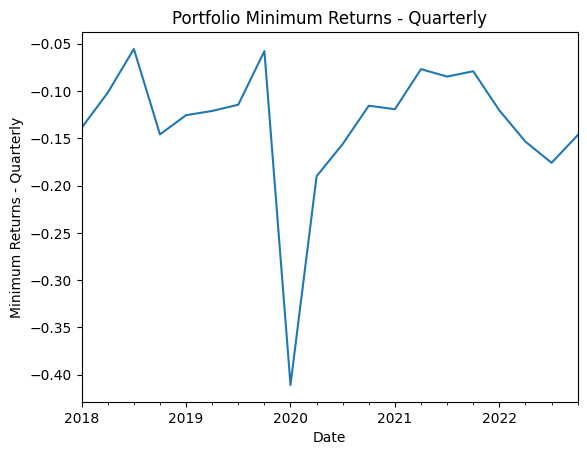

In [170]:
# Computing the minimum portfolio return in each calendar quarter to assess downside risk.
# This helps identify the worst return experienced in each quarter, highlighting periods of maximum drawdowns.
min_returns_quarterly = ptf_returns.resample('Q').min().dropna()
min_returns_quarterly.plot().set_ylabel("Minimum Returns - Quarterly")
plt.title('Portfolio Minimum Returns - Quarterly')
plt.show()



For k=3:
Silhouette Score: 0.5144
Davies-Bouldin Index: 0.3113
Calinski-Harabasz Index: 39.2406
Suggested Stocks without PCA for k=3: ['JPM', 'NVDA', 'VOO']


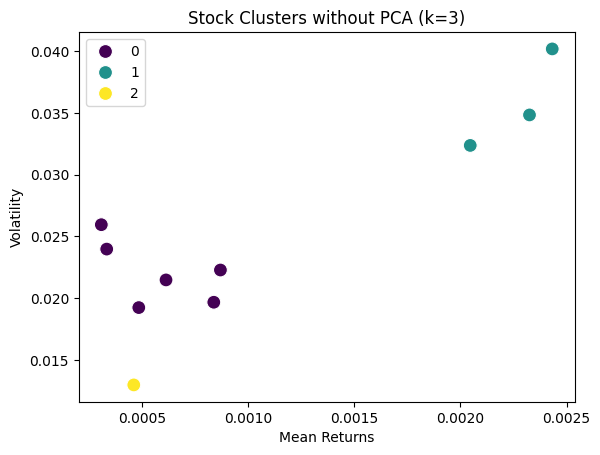


For k=4:
Silhouette Score: 0.5314
Davies-Bouldin Index: 0.3774
Calinski-Harabasz Index: 40.6486
Suggested Stocks without PCA for k=4: ['JPM', 'NVDA', 'VOO', 'INTC']


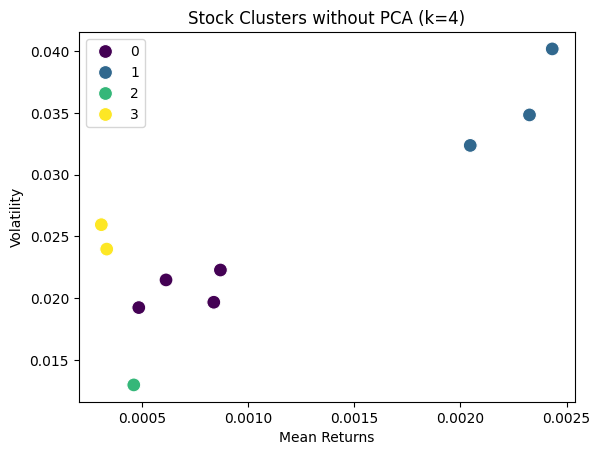


For k=5:
Silhouette Score: 0.3200
Davies-Bouldin Index: 0.4331
Calinski-Harabasz Index: 45.4542
Suggested Stocks without PCA for k=5: ['JPM', 'AMD', 'VOO', 'INTC', 'NVDA']


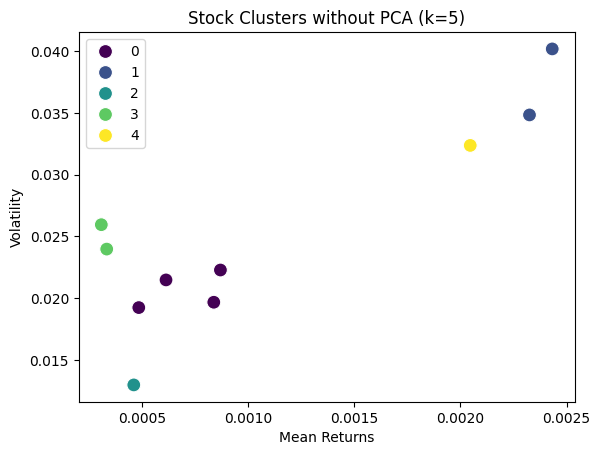


For k=6:
Silhouette Score: 0.3158
Davies-Bouldin Index: 0.2569
Calinski-Harabasz Index: 54.0429
Suggested Stocks without PCA for k=6: ['JPM', 'AMD', 'VOO', 'INTC', 'NVDA', 'TSLA']


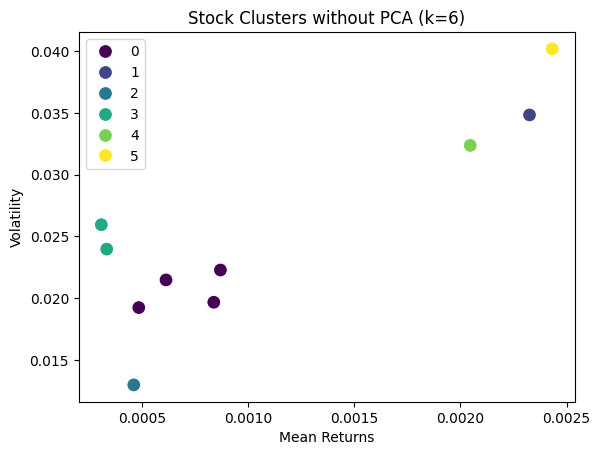


For k=7:
Silhouette Score: 0.2103
Davies-Bouldin Index: 0.3632
Calinski-Harabasz Index: 69.4110
Suggested Stocks without PCA for k=7: ['JPM', 'AMD', 'VOO', 'INTC', 'NVDA', 'TSLA', 'GOOG']


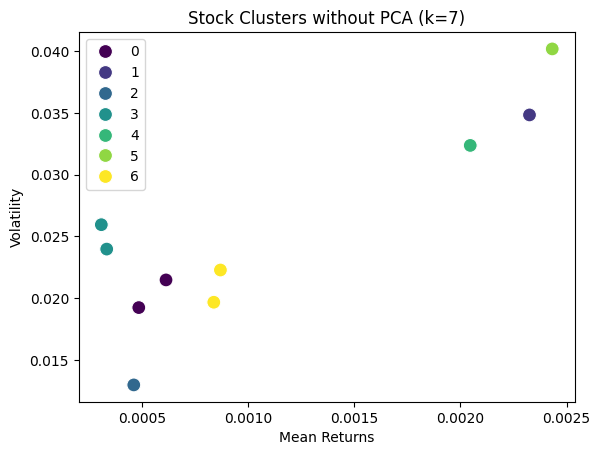


For k=8:
Silhouette Score: 0.1488
Davies-Bouldin Index: 0.2540
Calinski-Harabasz Index: 65.9071
Suggested Stocks without PCA for k=8: ['JPM', 'AMD', 'VOO', 'INTC', 'TSLA', 'NVDA', 'AMZN', 'GOOG']


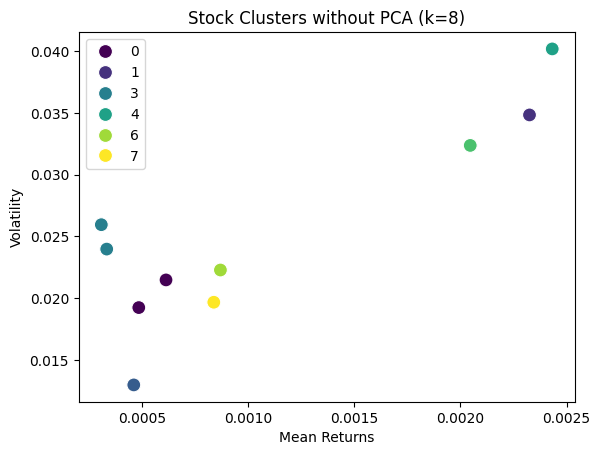


For k=9:
Silhouette Score: 0.1087
Davies-Bouldin Index: 0.1265
Calinski-Harabasz Index: 76.6627
Suggested Stocks without PCA for k=9: ['MS', 'AMD', 'VOO', 'INTC', 'TSLA', 'NVDA', 'AMZN', 'GOOG', 'JPM']


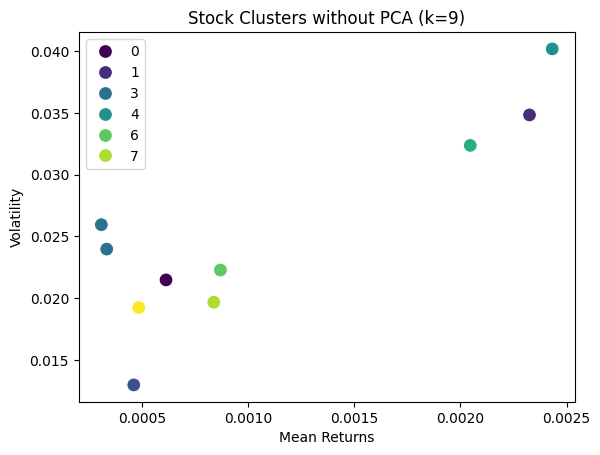

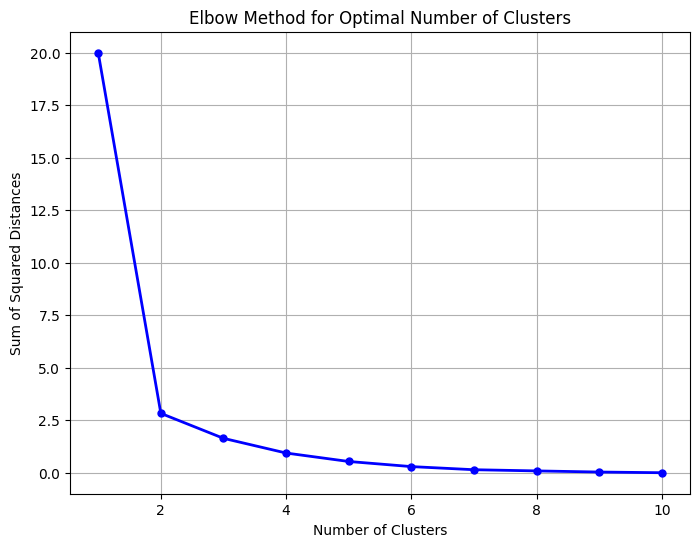

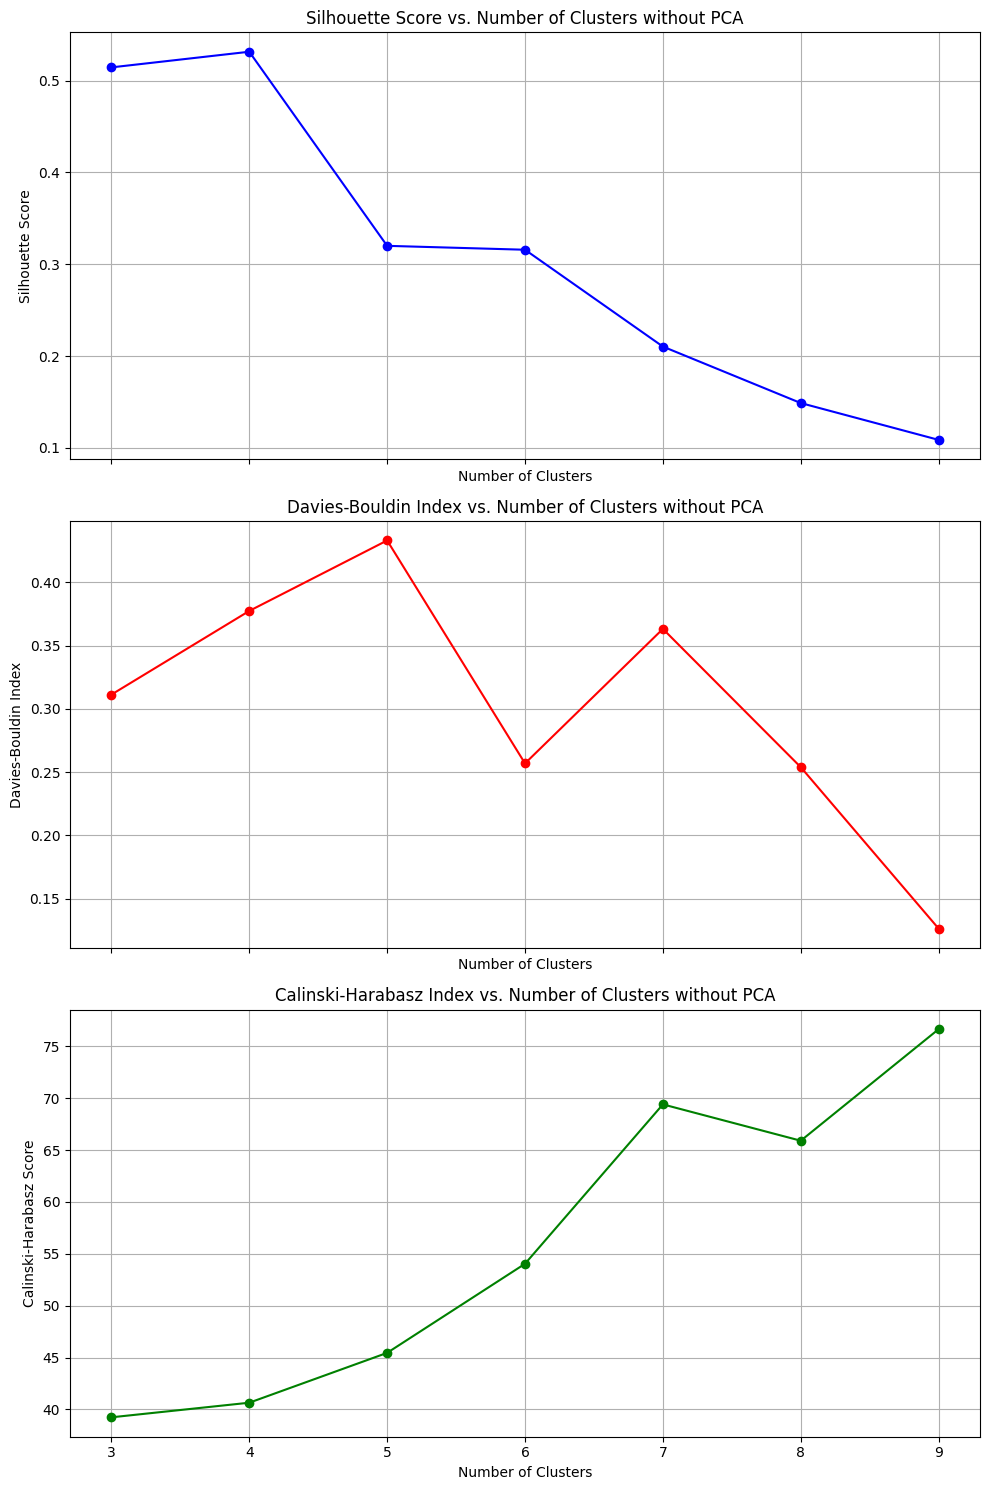


Clustering with PCA

For k=3:
Silhouette Score: 0.3922
Davies-Bouldin Index: 0.7028
Calinski-Harabasz Index: 9.0831
Suggested Stocks with PCA for k=3: ['JPM', 'NVDA', 'VOO']


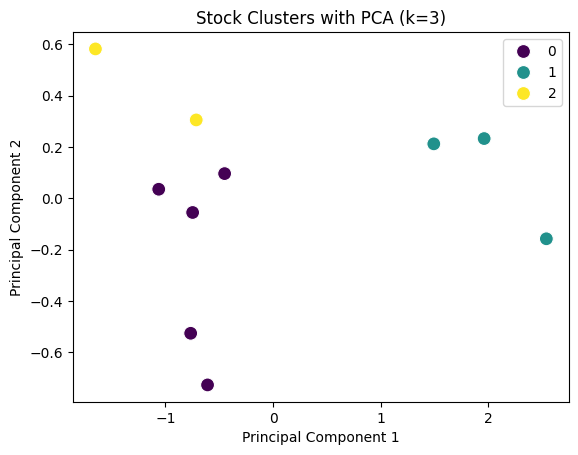


For k=4:
Silhouette Score: 0.5294
Davies-Bouldin Index: 0.3735
Calinski-Harabasz Index: 20.6683
Suggested Stocks with PCA for k=4: ['JPM', 'NVDA', 'VOO', 'INTC']


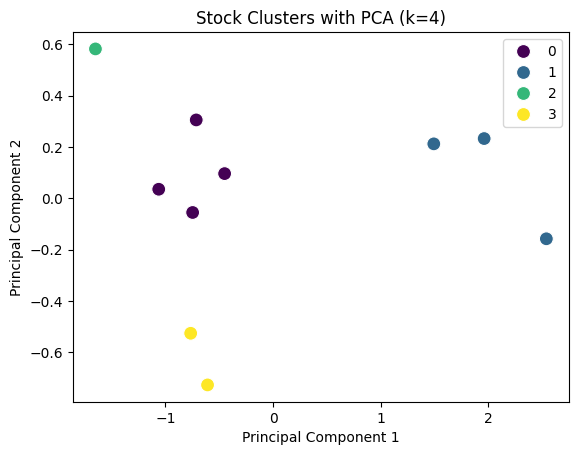


For k=5:
Silhouette Score: 0.4280
Davies-Bouldin Index: 0.3187
Calinski-Harabasz Index: 17.4546
Suggested Stocks with PCA for k=5: ['JPM', 'NVDA', 'VOO', 'INTC', 'GOOG']


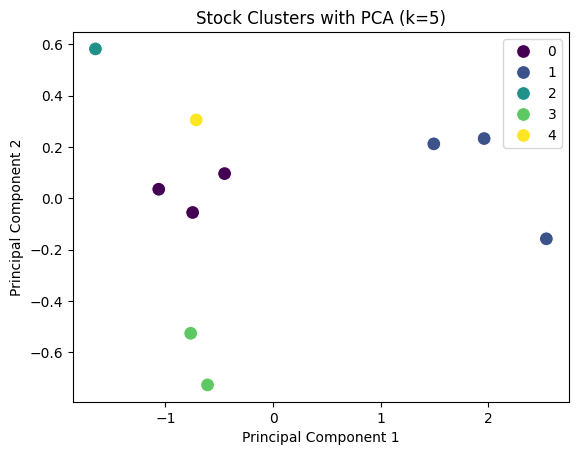


For k=6:
Silhouette Score: 0.4048
Davies-Bouldin Index: 0.2447
Calinski-Harabasz Index: 39.2558
Suggested Stocks with PCA for k=6: ['JPM', 'NVDA', 'VOO', 'INTC', 'GOOG', 'TSLA']


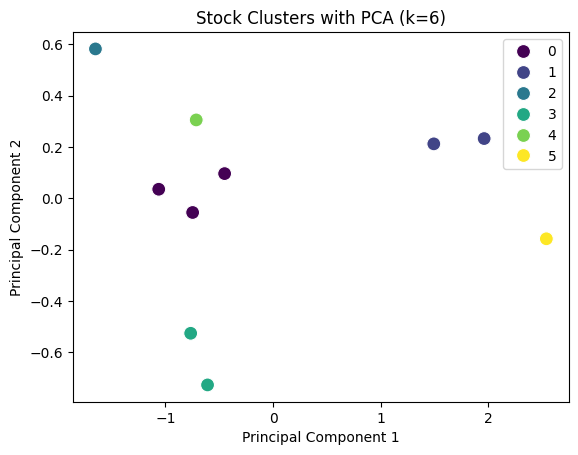


For k=7:
Silhouette Score: 0.2690
Davies-Bouldin Index: 0.2082
Calinski-Harabasz Index: 40.2120
Suggested Stocks with PCA for k=7: ['JPM', 'NVDA', 'VOO', 'INTC', 'GOOG', 'TSLA', 'F']


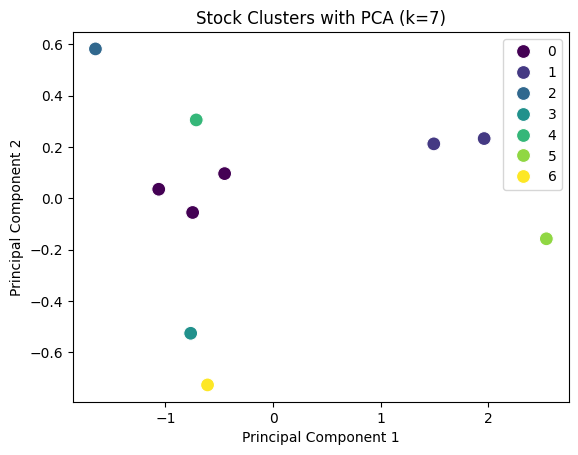


For k=8:
Silhouette Score: 0.1988
Davies-Bouldin Index: 0.1977
Calinski-Harabasz Index: 48.6071
Suggested Stocks with PCA for k=8: ['JPM', 'NVDA', 'INTC', 'VOO', 'TSLA', 'GOOG', 'F', 'AMZN']


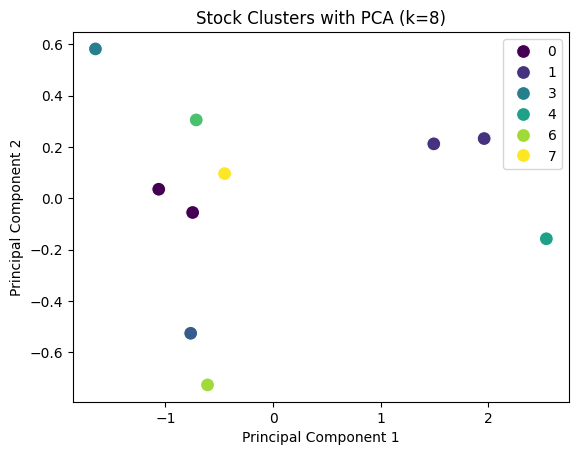


For k=9:
Silhouette Score: 0.0571
Davies-Bouldin Index: 0.1665
Calinski-Harabasz Index: 44.1250
Suggested Stocks with PCA for k=9: ['JPM', 'AMD', 'INTC', 'VOO', 'TSLA', 'GOOG', 'F', 'AMZN', 'NVDA']


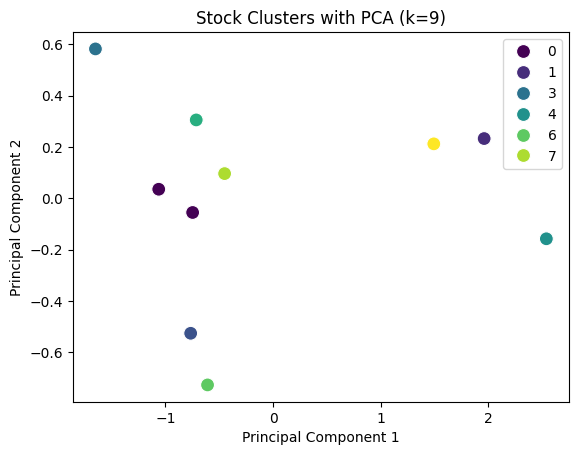

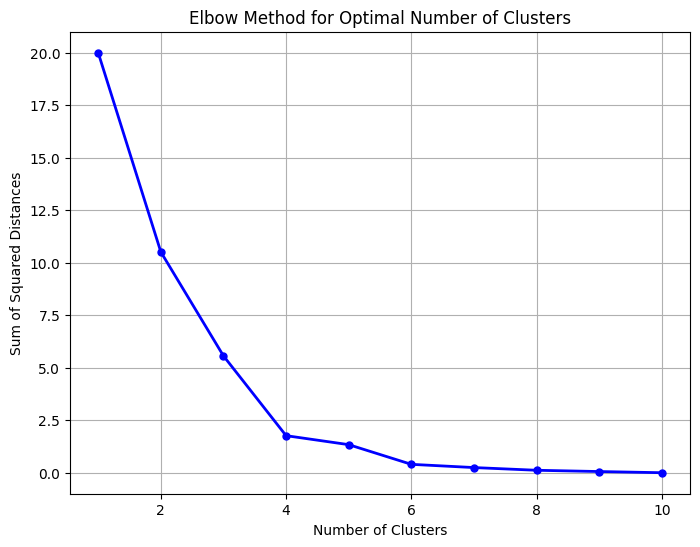

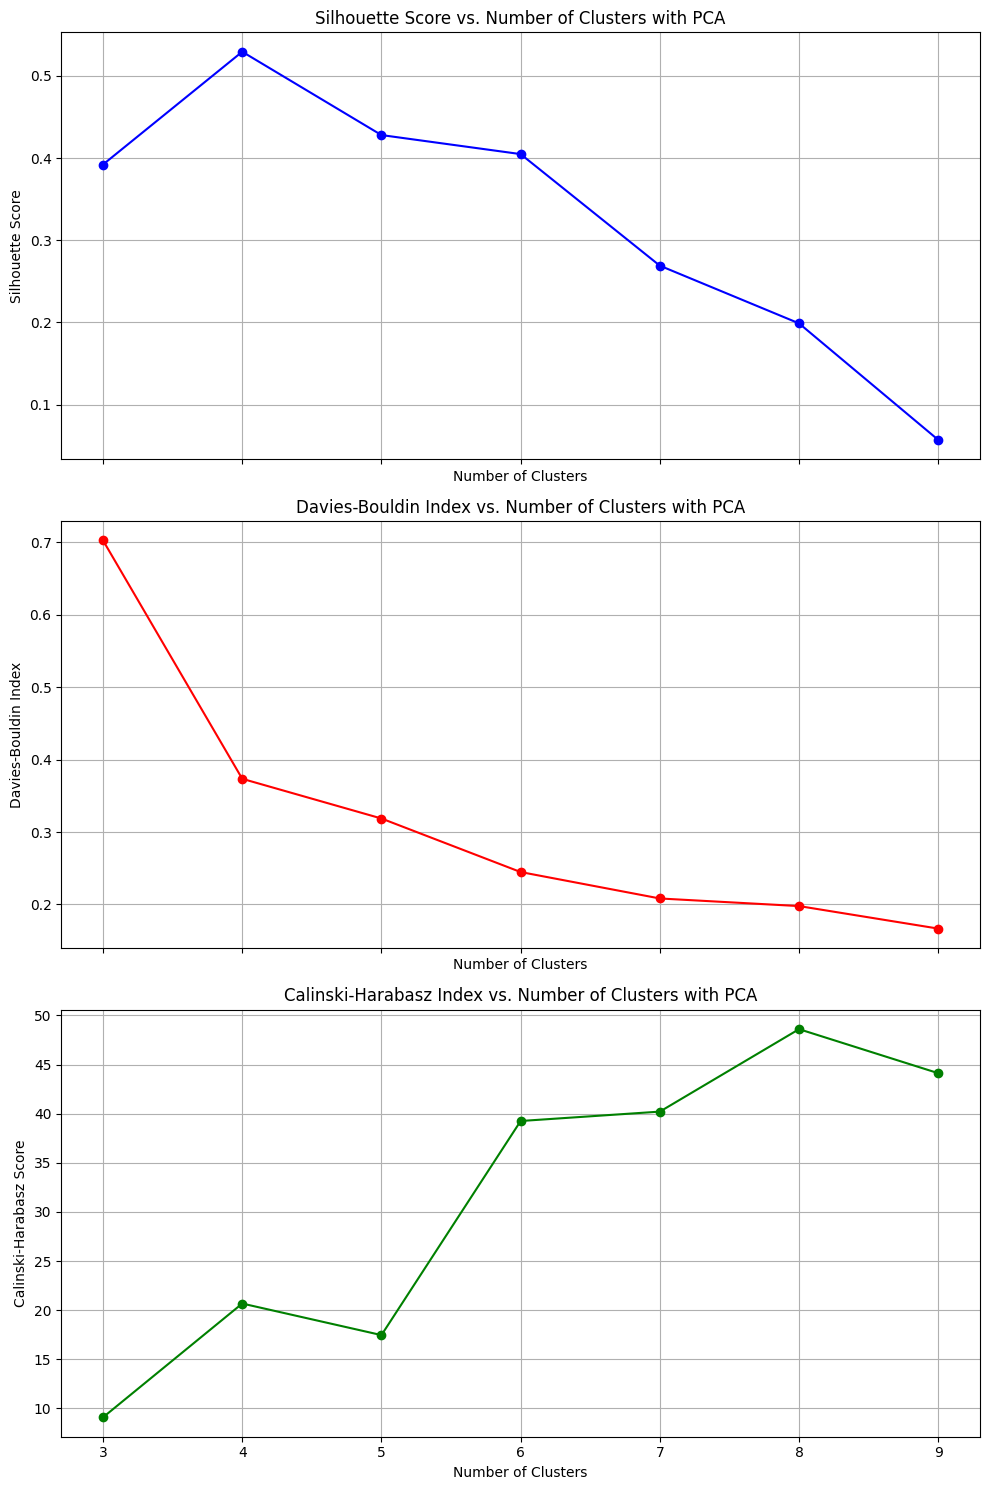

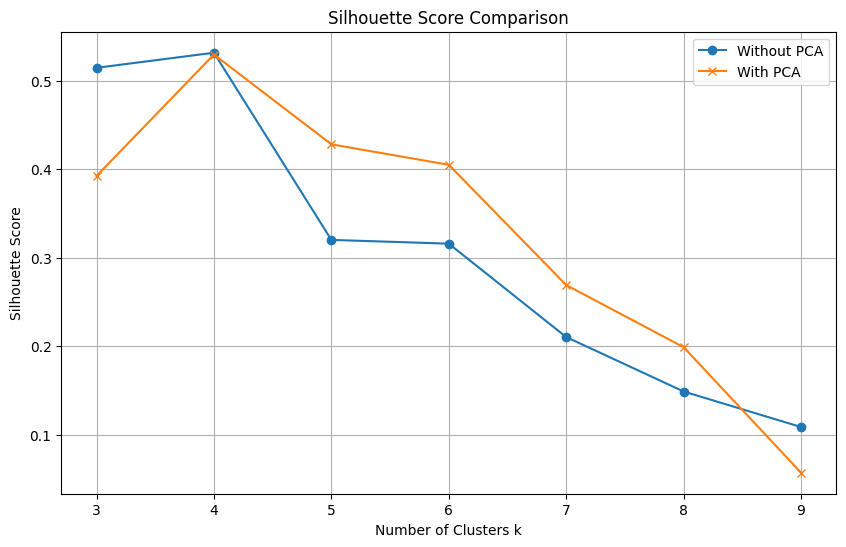

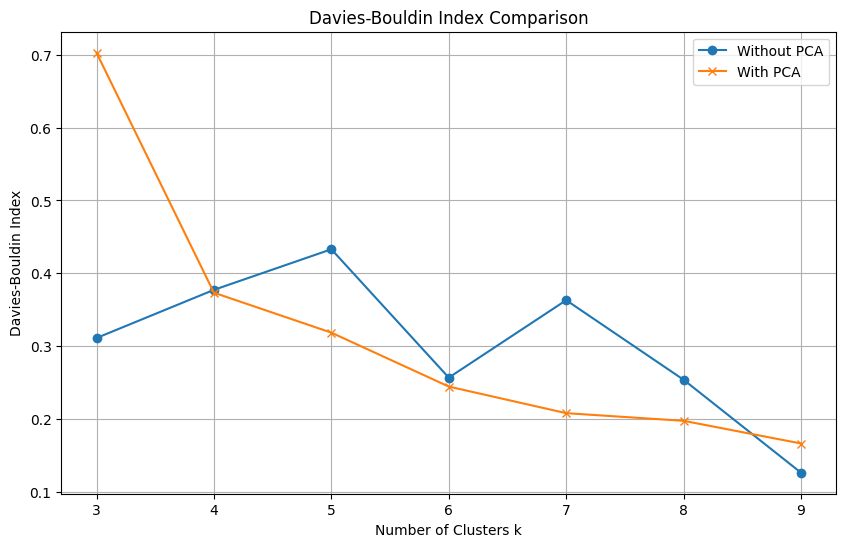

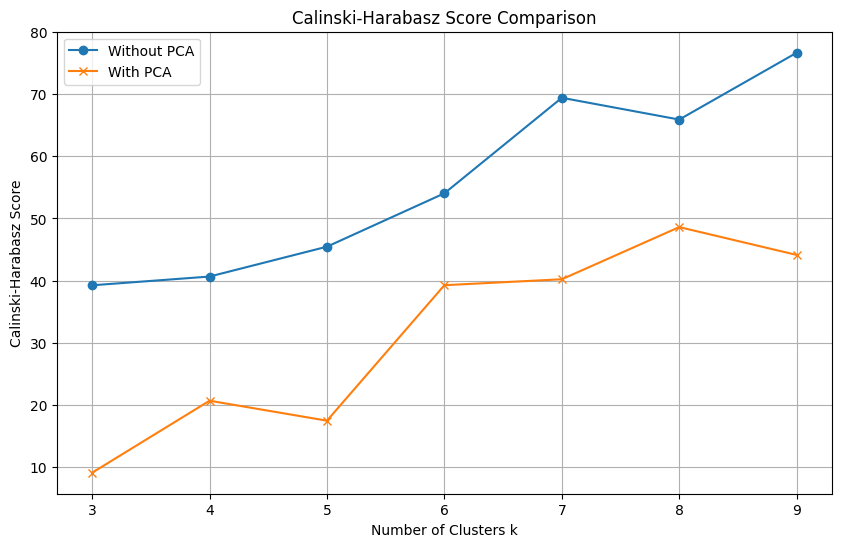

In [171]:
# Running the complete K-Means clustering workflow on stock volatility features, both with and without PCA.
# This pipeline prepares the data, performs clustering, evaluates metrics, and generates diagnostic plots to identify optimal cluster structure.
from src.mykmeans import MyKMeans

kmeans = MyKMeans()
kmeans.set_stock_data()
kmeans.volatility_feature_engineering()

cluster_range = range(3, 10)
kmeans.volatility_clustering_without_pca(range_n_clusters=cluster_range)
kmeans.plot_elbow_method()
kmeans.plot_metrics_without_pca()
kmeans.volatility_clustering_with_pca(range_n_clusters=cluster_range)
kmeans.plot_elbow_method()
kmeans.plot_metrics_pca()

kmeans.plot_metrics()


Without PCA - n_clusters=4, Silhouette Score: 0.41, Davies-Bouldin Index: 0.64, Calinski-Harabasz Index: 18.94


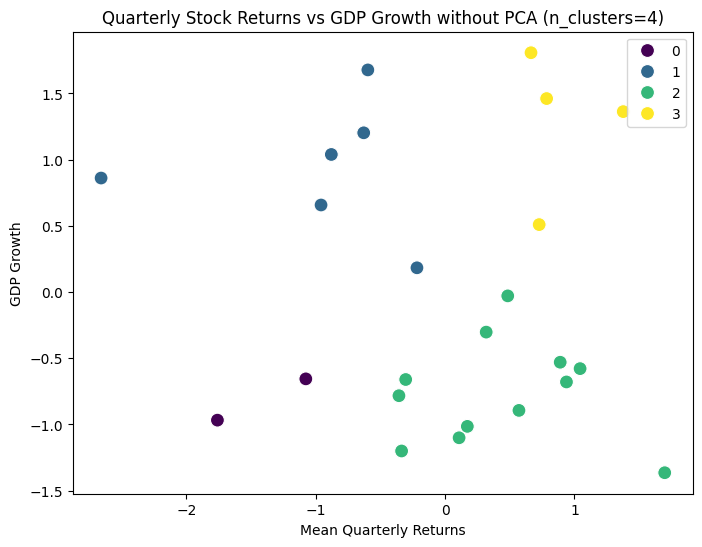

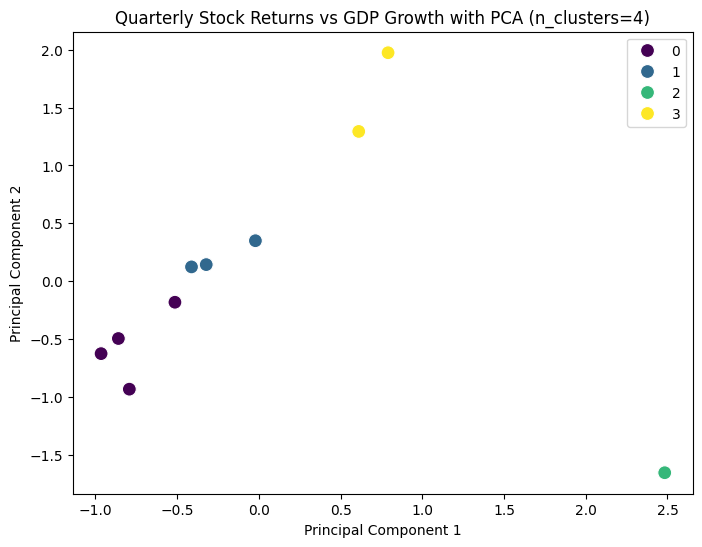

With PCA - n_clusters=4, Silhouette Score: 0.48, Davies-Bouldin Index: 0.35, Calinski-Harabasz Index: 50.32


In [172]:
# Applying K-Means clustering using GDP-linked quarterly features to identify economic patterns affecting stock groups.
# This sequence loads stock data, engineers GDP-based features, and performs clustering both with and without PCA for comparison.
from src.mykmeans import MyKMeans

kmeans = MyKMeans()
kmeans.set_stock_data()
kmeans.gdp_quarterly_feature_engineering()

kmeans.gdp_quarterly_clustering_without_pca()
kmeans.gdp_quarterly_clustering_pca()


Without PCA - n_clusters=4, Silhouette Score: 0.39, Davies-Bouldin Index: 0.88, Calinski-Harabasz Index: 17.65


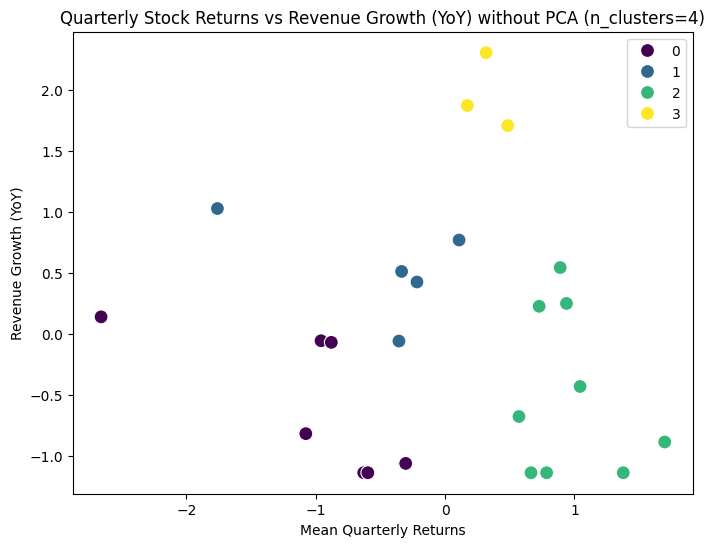

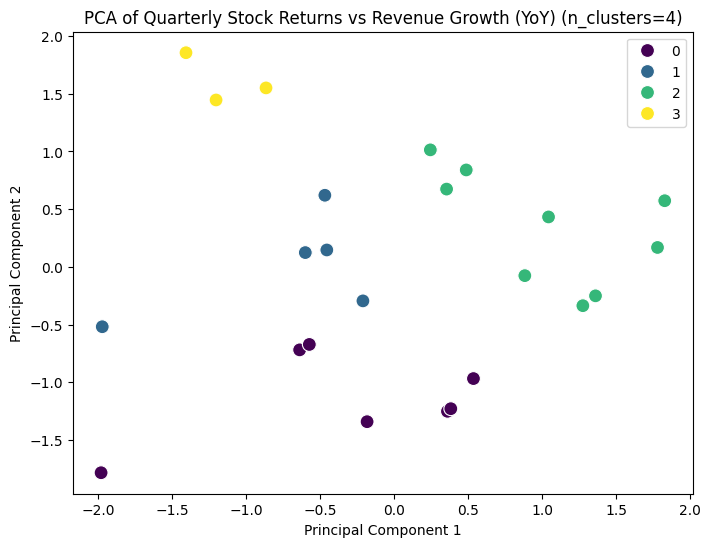

With PCA - n_clusters=4, Silhouette Score: 0.39, Davies-Bouldin Index: 0.88, Calinski-Harabasz Index: 17.65
Without PCA - n_clusters=4, Silhouette Score: 0.43, Davies-Bouldin Index: 0.75, Calinski-Harabasz Index: 25.61


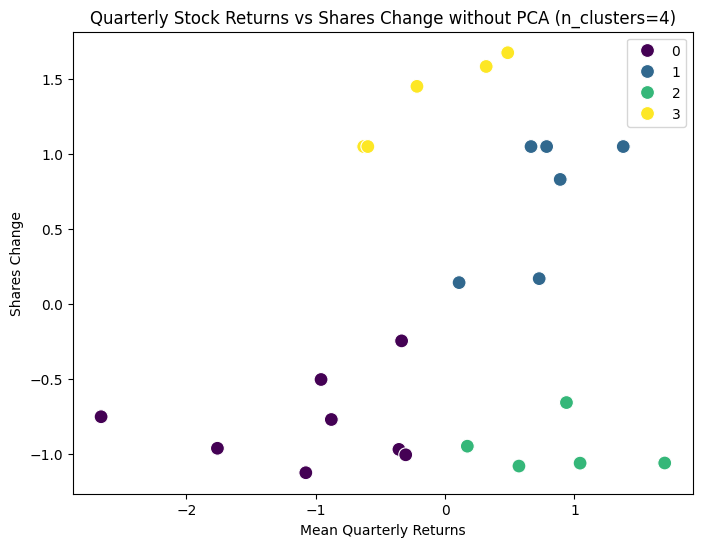

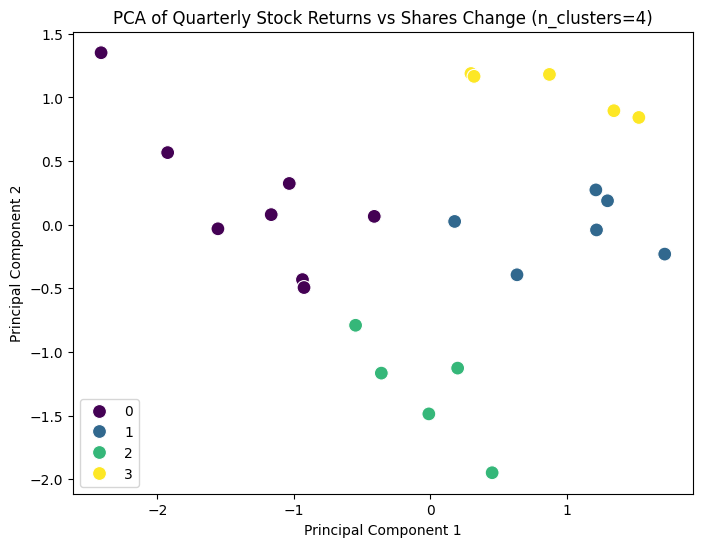

With PCA - n_clusters=4, Silhouette Score: 0.43, Davies-Bouldin Index: 0.75, Calinski-Harabasz Index: 25.61
Without PCA - n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.76, Calinski-Harabasz Index: 22.79


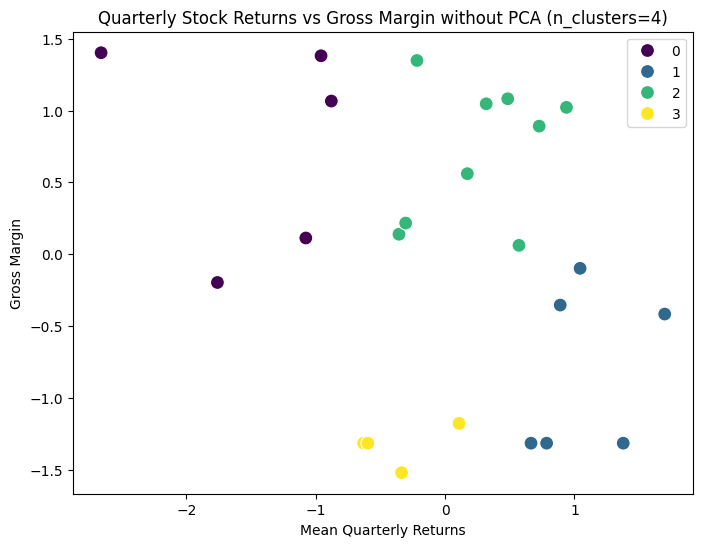

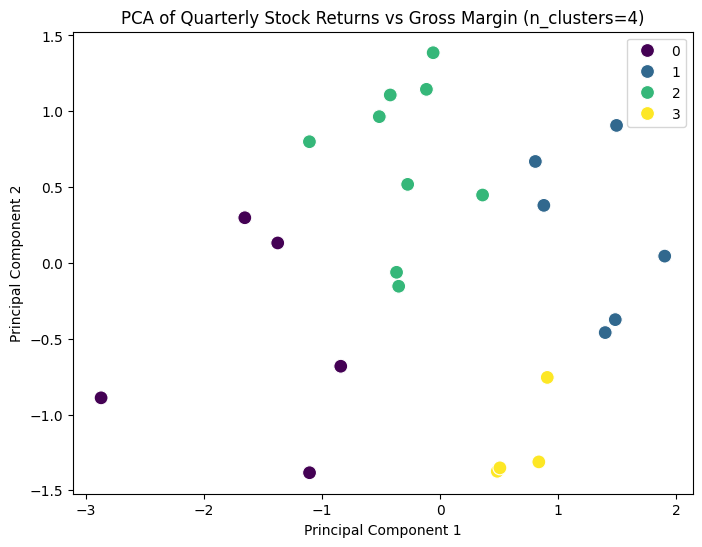

With PCA - n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.76, Calinski-Harabasz Index: 22.79
Without PCA - n_clusters=4, Silhouette Score: 0.28, Davies-Bouldin Index: 1.01, Calinski-Harabasz Index: 14.14


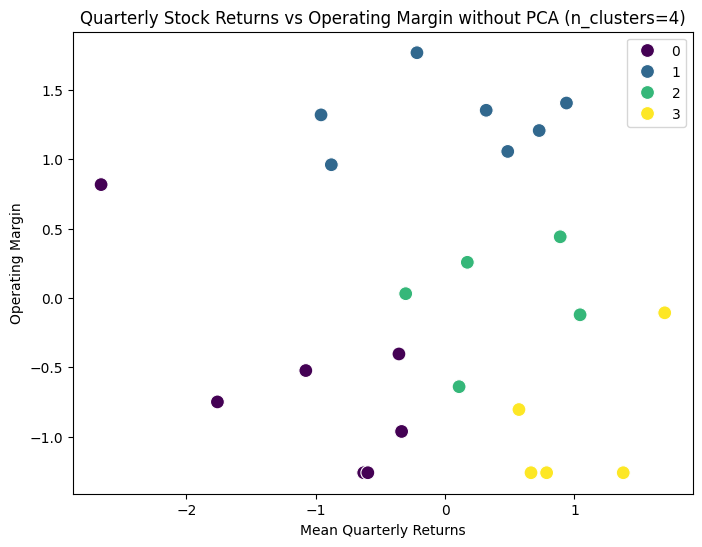

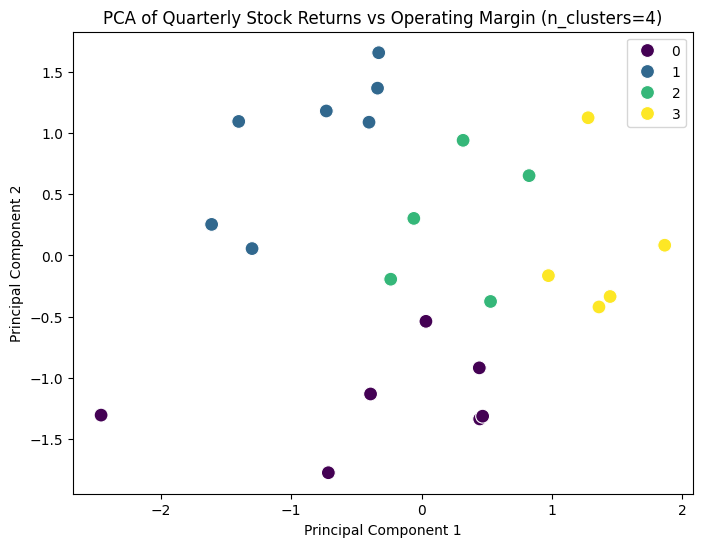

With PCA - n_clusters=4, Silhouette Score: 0.28, Davies-Bouldin Index: 1.01, Calinski-Harabasz Index: 14.14
Without PCA - n_clusters=4, Silhouette Score: 0.44, Davies-Bouldin Index: 0.69, Calinski-Harabasz Index: 24.58


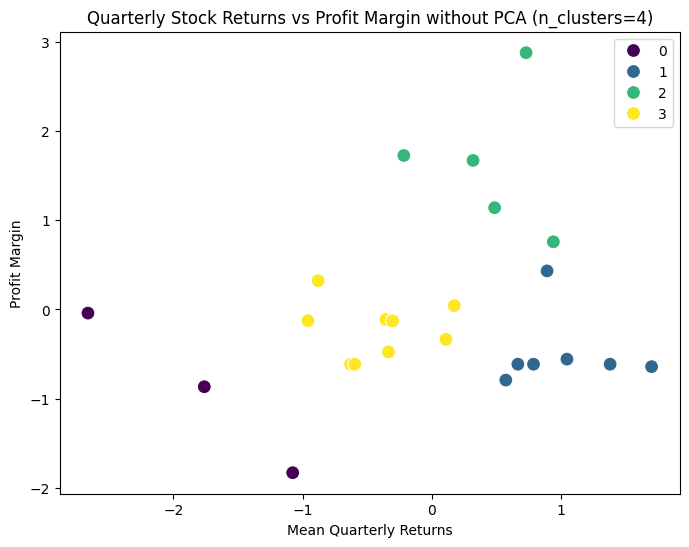

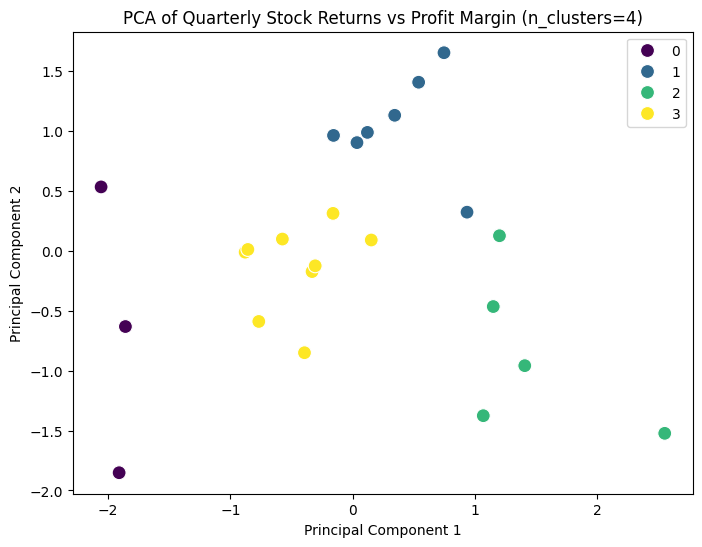

With PCA - n_clusters=4, Silhouette Score: 0.44, Davies-Bouldin Index: 0.69, Calinski-Harabasz Index: 24.58
Without PCA - n_clusters=4, Silhouette Score: 0.32, Davies-Bouldin Index: 0.80, Calinski-Harabasz Index: 15.47


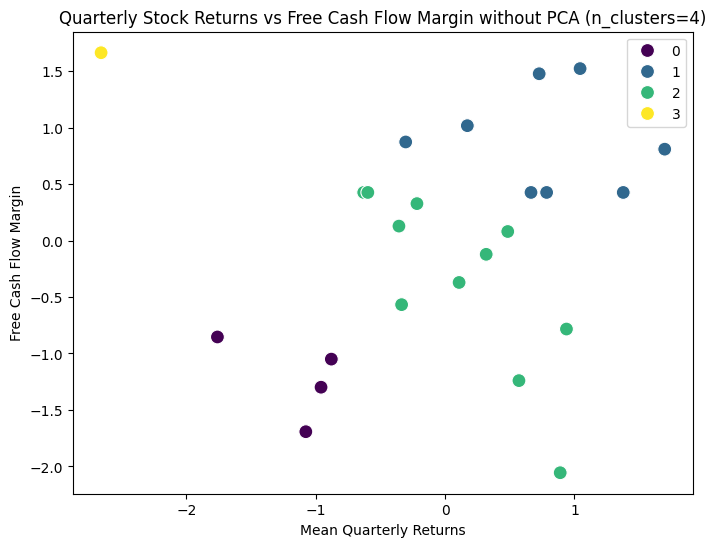

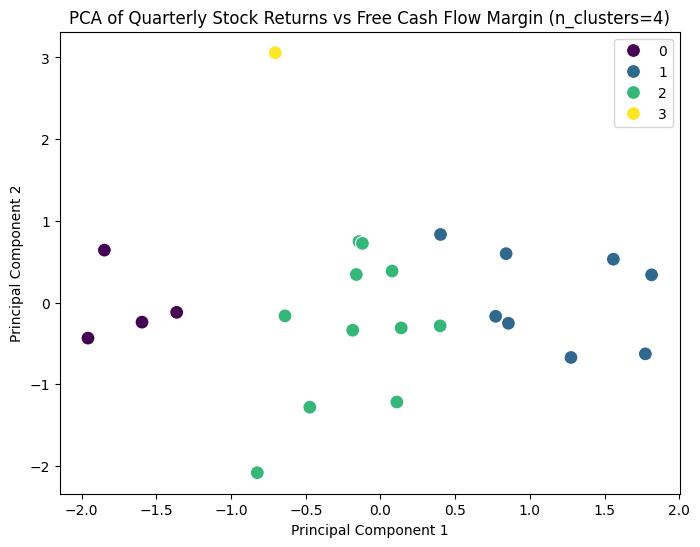

With PCA - n_clusters=4, Silhouette Score: 0.32, Davies-Bouldin Index: 0.80, Calinski-Harabasz Index: 15.47
Without PCA - n_clusters=4, Silhouette Score: 0.48, Davies-Bouldin Index: 0.66, Calinski-Harabasz Index: 27.84


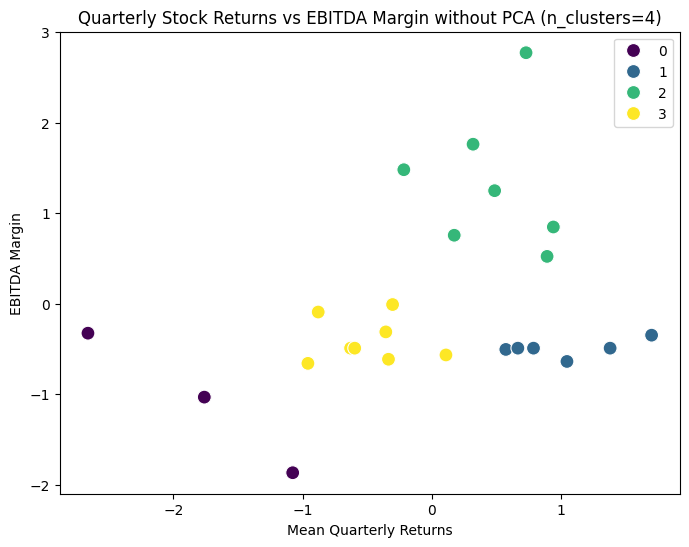

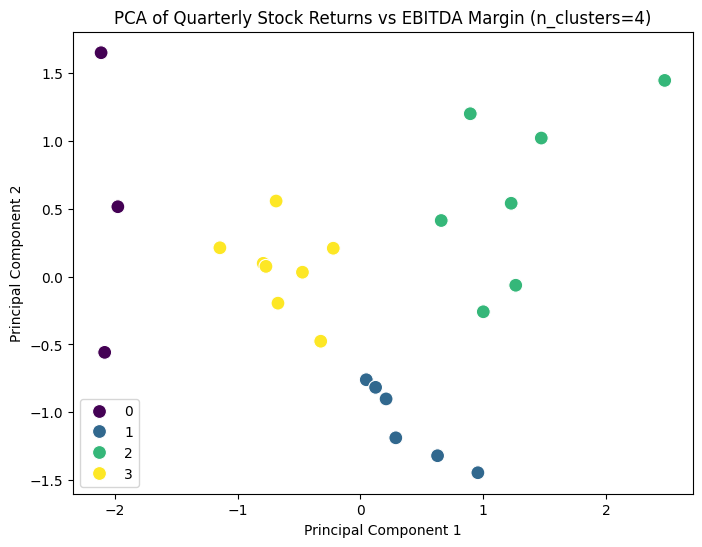

With PCA - n_clusters=4, Silhouette Score: 0.48, Davies-Bouldin Index: 0.66, Calinski-Harabasz Index: 27.84
Without PCA - n_clusters=4, Silhouette Score: 0.35, Davies-Bouldin Index: 0.99, Calinski-Harabasz Index: 18.55


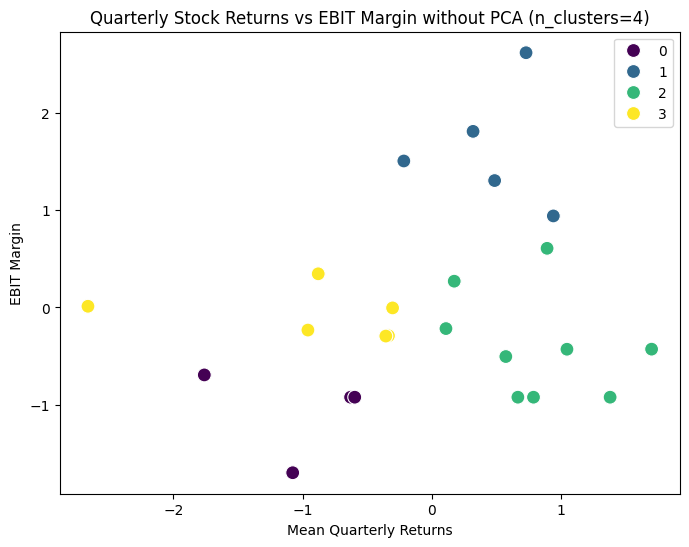

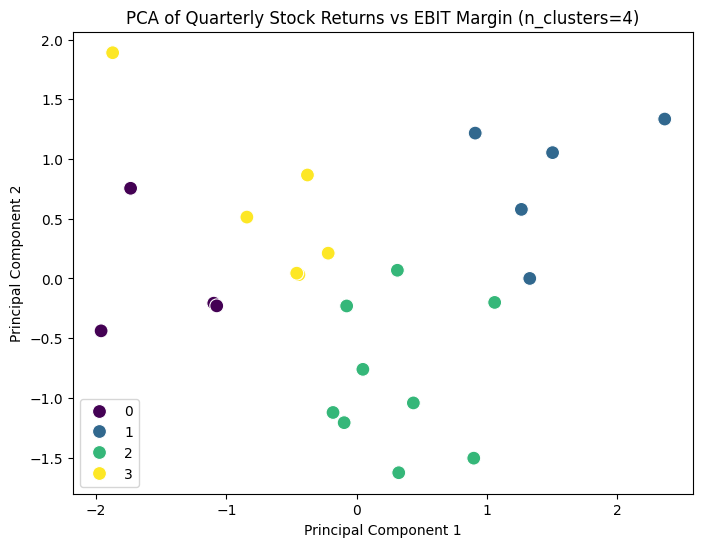

With PCA - n_clusters=4, Silhouette Score: 0.35, Davies-Bouldin Index: 0.99, Calinski-Harabasz Index: 18.55
Without PCA - n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.61, Calinski-Harabasz Index: 20.07


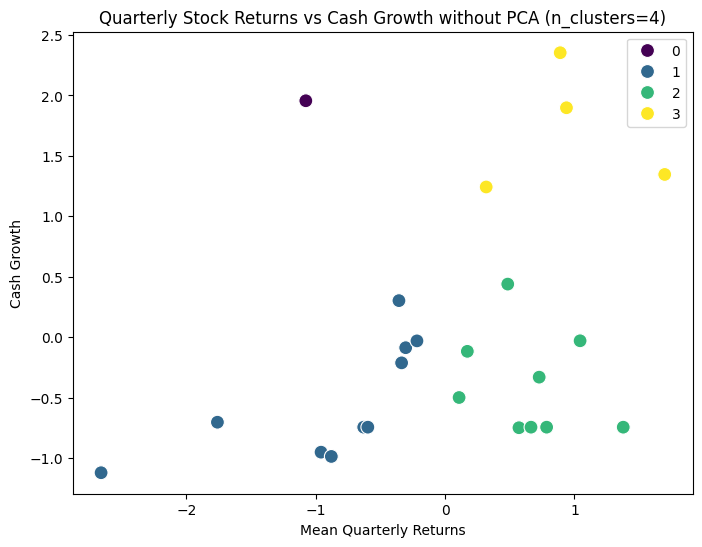

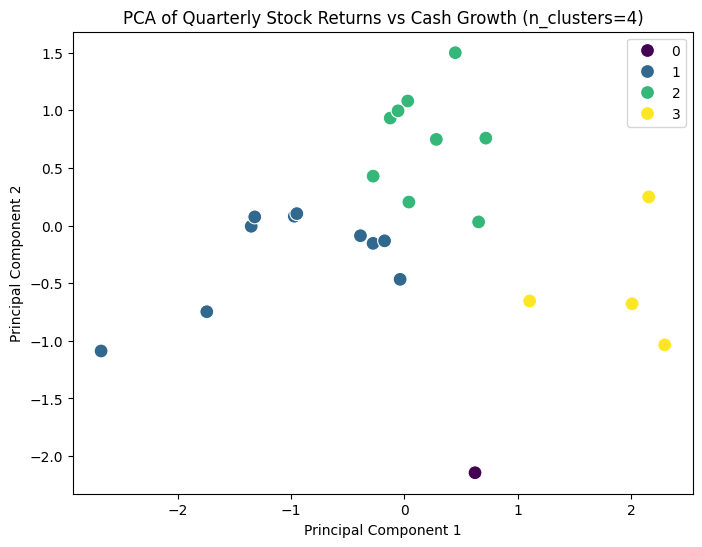

With PCA - n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.61, Calinski-Harabasz Index: 20.07
Without PCA - n_clusters=4, Silhouette Score: 0.49, Davies-Bouldin Index: 0.63, Calinski-Harabasz Index: 30.89


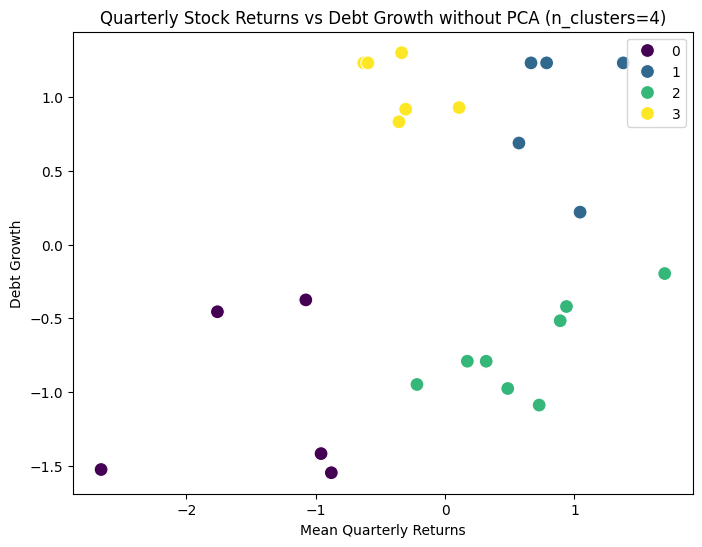

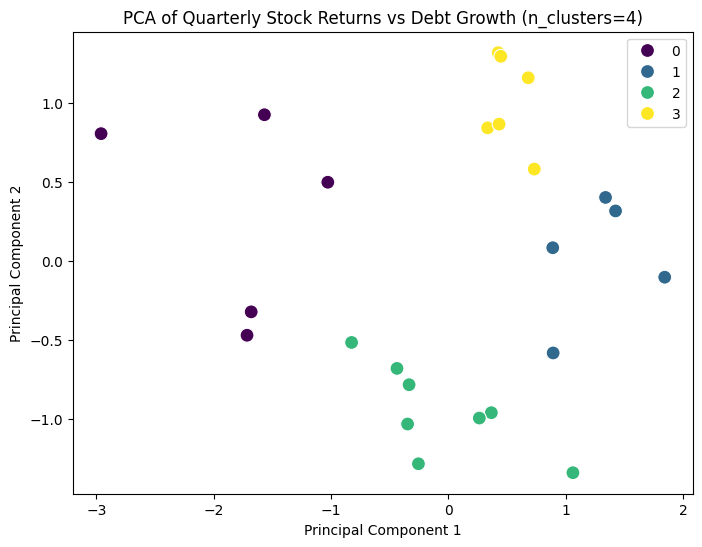

With PCA - n_clusters=4, Silhouette Score: 0.49, Davies-Bouldin Index: 0.63, Calinski-Harabasz Index: 30.89


In [173]:
# Generating quarterly return and volatility features and applying K-Means clustering to group stocks into 4 clusters.
# This step prepares time-aggregated features and segments stocks based on their quarterly performance characteristics.
from src.mykmeans import MyKMeans

kmeans = MyKMeans()
kmeans.set_stock_data()
kmeans.quarterly_feature_engineering(n_clusters=4)


Without PCA - REAINTRATREARAT10Y: n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.90, Calinski-Harabasz Index: 57.14


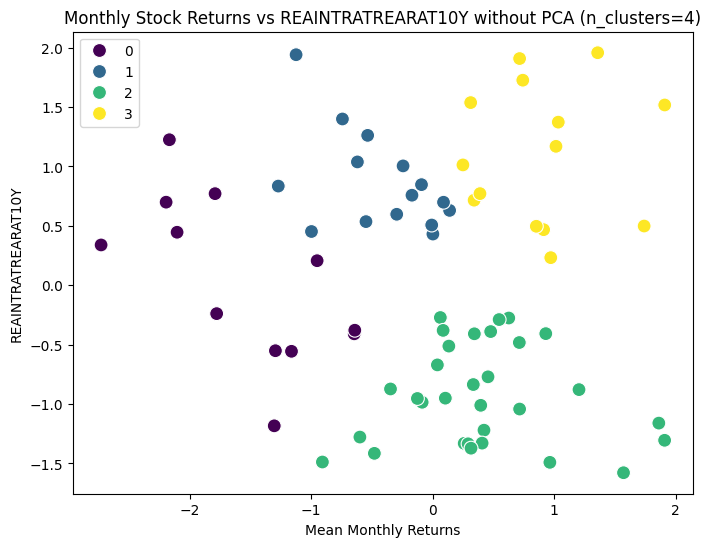

Without PCA - MEDCPIM158SFRBCLE: n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.84, Calinski-Harabasz Index: 59.47


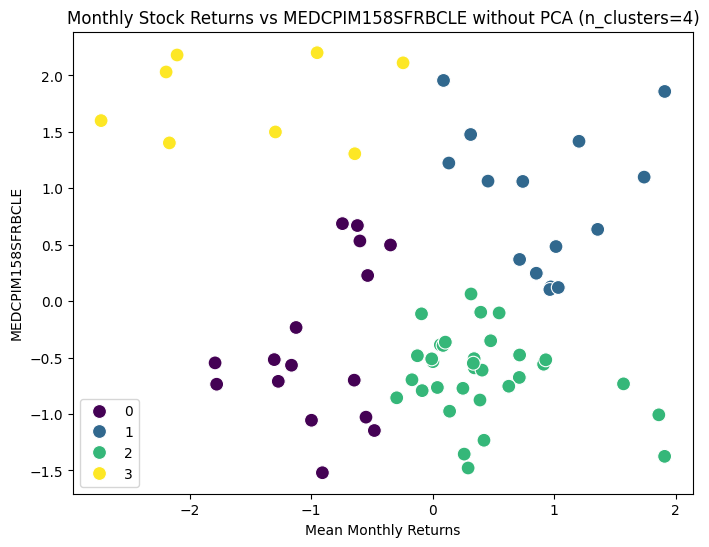

Without PCA - PSAVERT: n_clusters=4, Silhouette Score: 0.36, Davies-Bouldin Index: 0.81, Calinski-Harabasz Index: 65.01


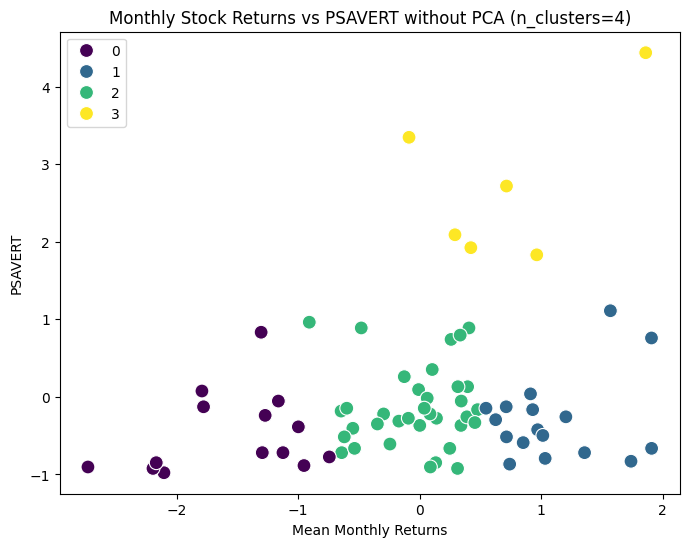

Without PCA - UNRATE: n_clusters=4, Silhouette Score: 0.48, Davies-Bouldin Index: 0.73, Calinski-Harabasz Index: 78.83


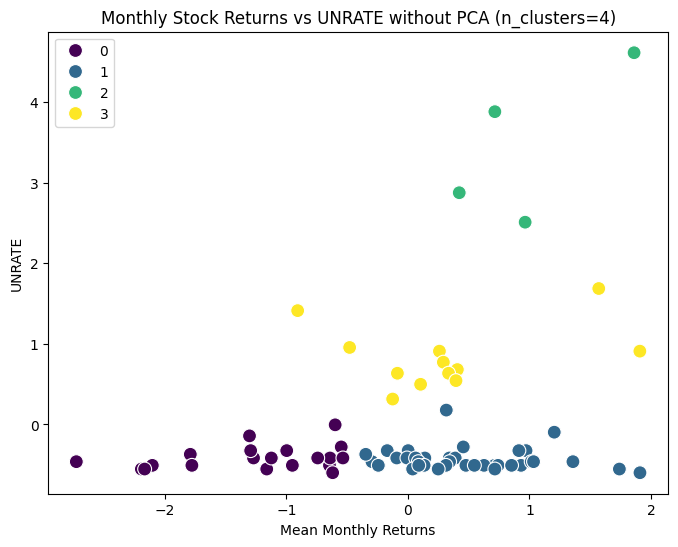

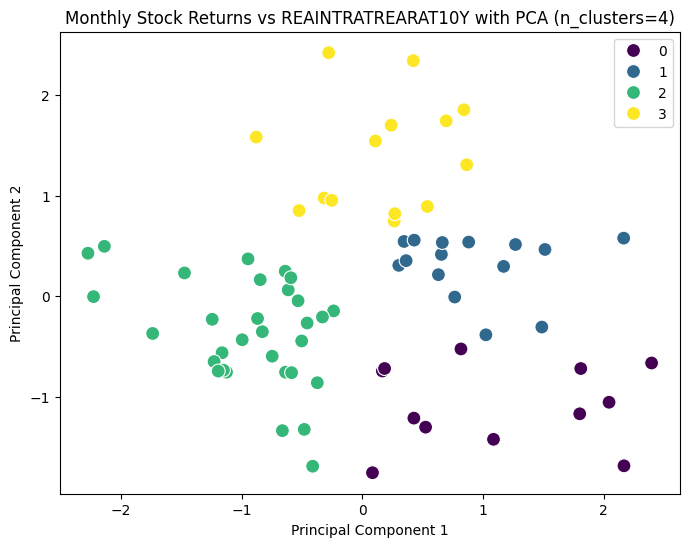

With PCA - REAINTRATREARAT10Y: n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.90, Calinski-Harabasz Index: 57.14


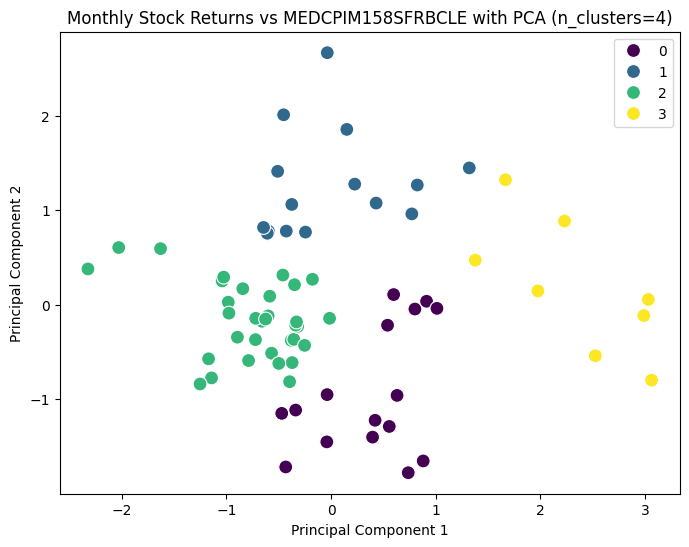

With PCA - MEDCPIM158SFRBCLE: n_clusters=4, Silhouette Score: 0.40, Davies-Bouldin Index: 0.84, Calinski-Harabasz Index: 59.47


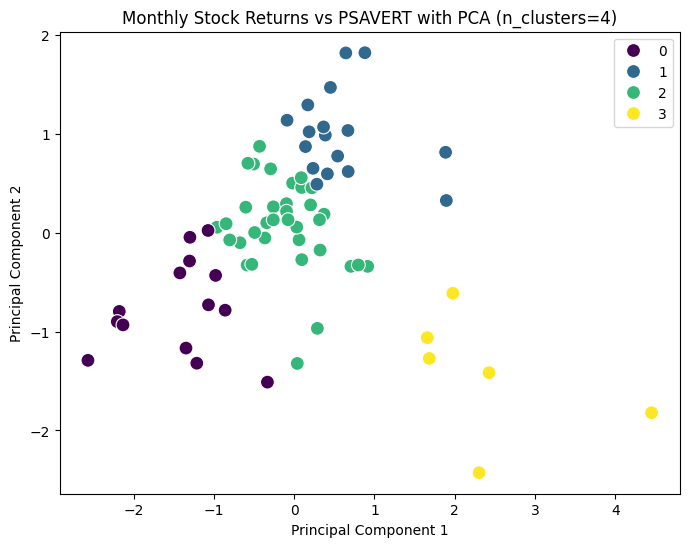

With PCA - PSAVERT: n_clusters=4, Silhouette Score: 0.36, Davies-Bouldin Index: 0.81, Calinski-Harabasz Index: 65.01


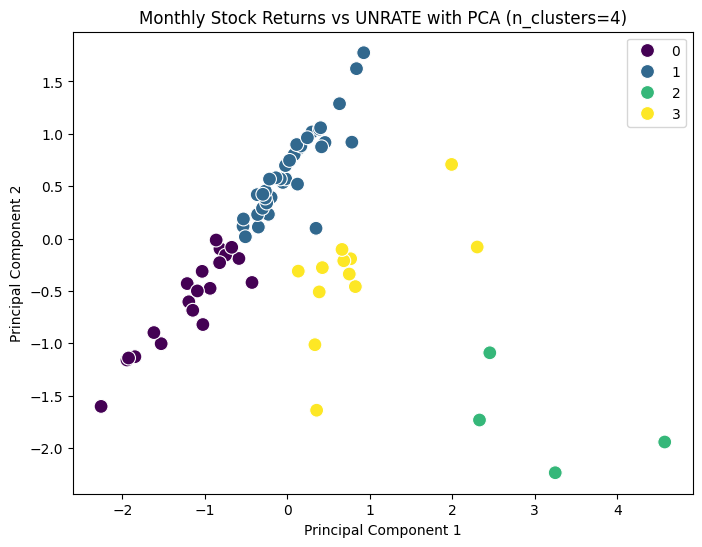

With PCA - UNRATE: n_clusters=4, Silhouette Score: 0.48, Davies-Bouldin Index: 0.73, Calinski-Harabasz Index: 78.83


In [174]:
# Performing clustering analysis on key macroeconomic indicators to uncover patterns in broader economic conditions.
# This workflow loads economic data and applies K-Means clustering both with and without PCA to compare clustering performance.
from src.mykmeans import MyKMeans

kmeans = MyKMeans()
kmeans.set_econ_data()
indicators = ['REAINTRATREARAT10Y', 'MEDCPIM158SFRBCLE', 'PSAVERT', 'UNRATE']
kmeans.economic_indicator_clustering_without_pca(indictors=indicators)
kmeans.economic_indicator_clustering_pca(indictors=indicators)


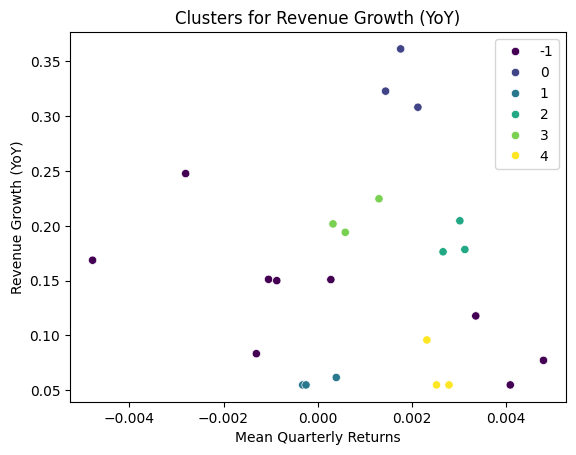

Metrics for Revenue Growth (YoY) - Silhouette: 0.2686858885557311, Davies Bouldin: 1.3827517294100897, Calinski Harabasz: 4.331919460881344


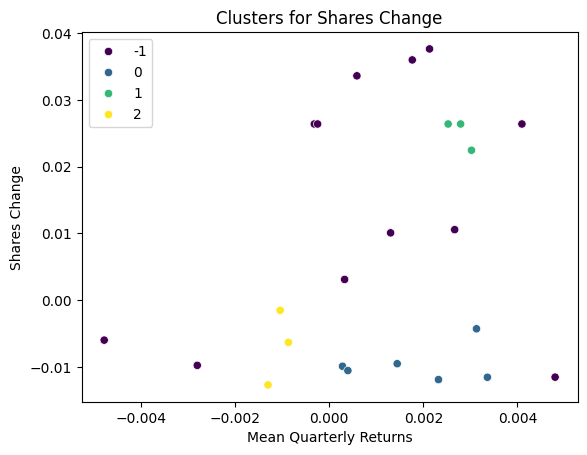

Metrics for Shares Change - Silhouette: 0.045166088330955034, Davies Bouldin: 1.2837910160615982, Calinski Harabasz: 3.9945292875912366


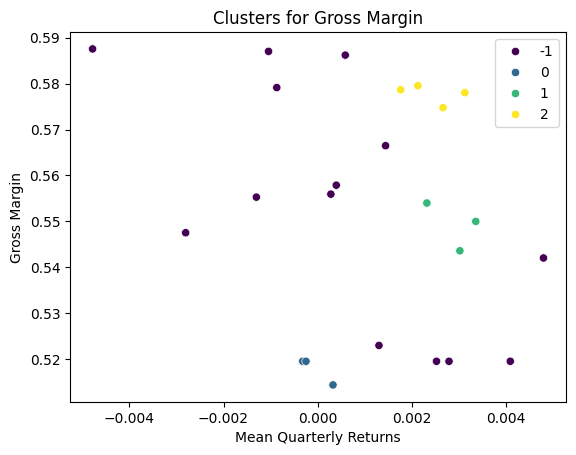

Metrics for Gross Margin - Silhouette: 0.11541374480849653, Davies Bouldin: 1.3004061716395185, Calinski Harabasz: 3.0736249294703653


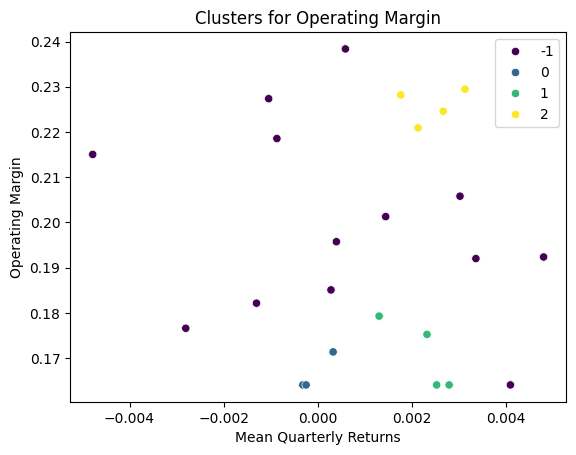

Metrics for Operating Margin - Silhouette: 0.1113142643865188, Davies Bouldin: 1.153798559617118, Calinski Harabasz: 4.3229135203715945


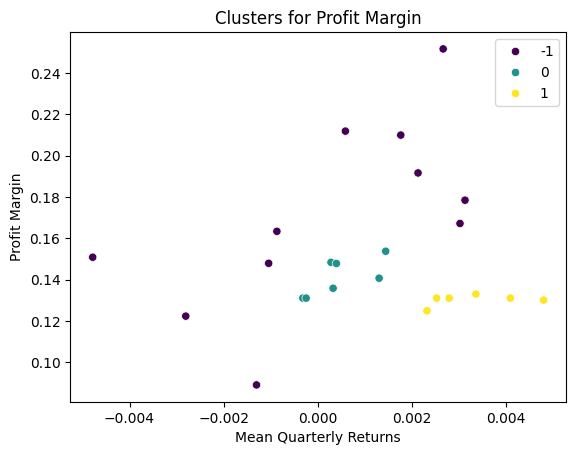

Metrics for Profit Margin - Silhouette: 0.219963150766309, Davies Bouldin: 1.7845580346945955, Calinski Harabasz: 4.747345969144539


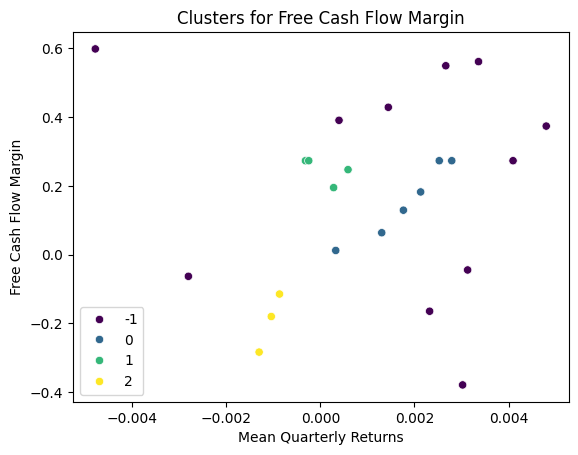

Metrics for Free Cash Flow Margin - Silhouette: 0.09260346199638729, Davies Bouldin: 4.395906097304474, Calinski Harabasz: 2.125539806238821


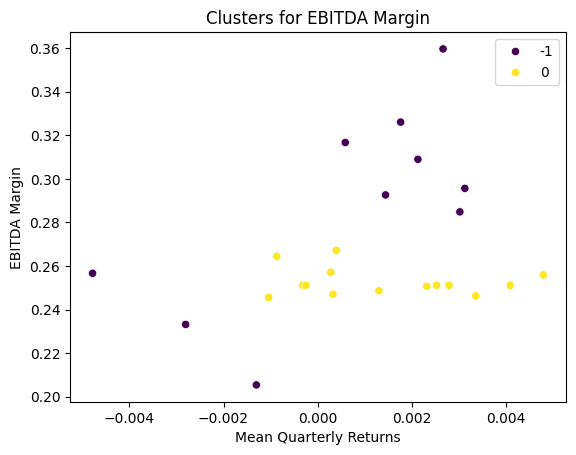

Metrics for EBITDA Margin - Silhouette: 0.2694961443899539, Davies Bouldin: 2.0799340532161135, Calinski Harabasz: 3.9880969386137632


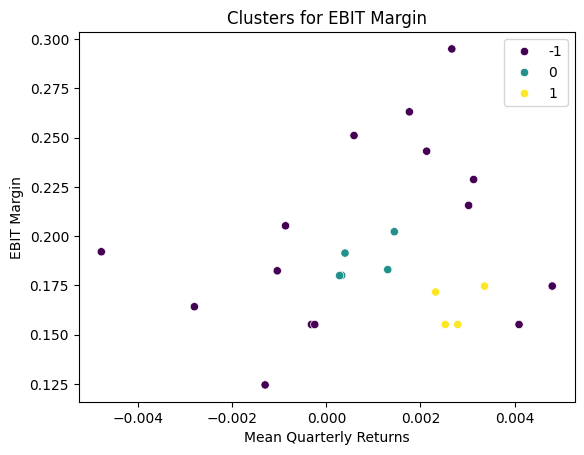

Metrics for EBIT Margin - Silhouette: 0.009788014561335498, Davies Bouldin: 4.28572114610447, Calinski Harabasz: 1.3688207919540978


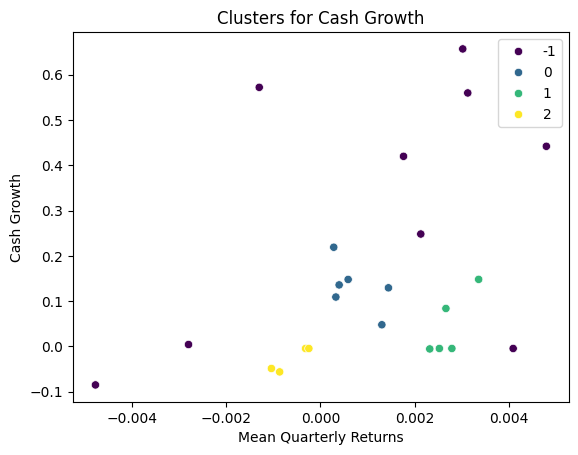

Metrics for Cash Growth - Silhouette: 0.24636834691813495, Davies Bouldin: 1.767427745094945, Calinski Harabasz: 2.9343351916214533


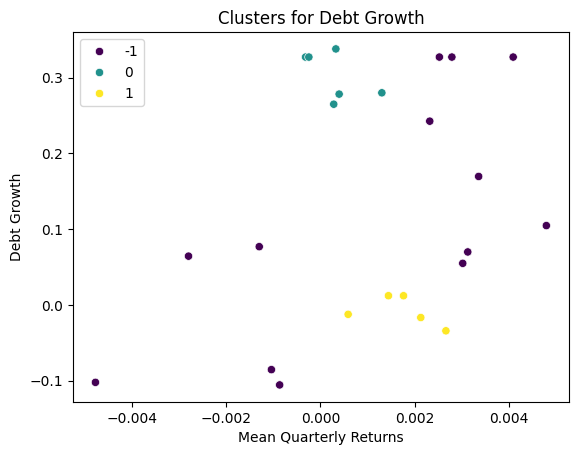

Metrics for Debt Growth - Silhouette: 0.16900062092447468, Davies Bouldin: 1.9647562499483453, Calinski Harabasz: 3.7377370292425445


In [175]:
# Running DBSCAN clustering on quarterly return features to identify natural groupings in stock performance.
# This method detects dense clusters without assuming any predefined number of groups, making it useful for pattern discovery.
dbscan.clustering_with_quarterly_returns()


AAPL


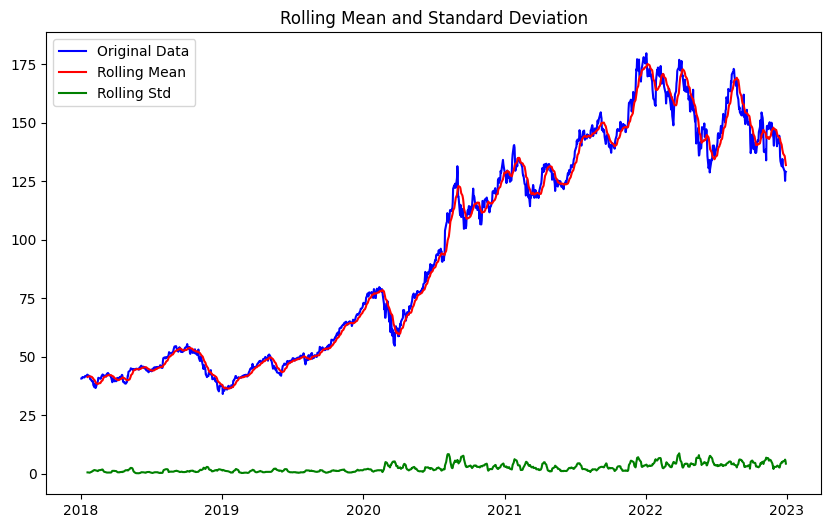

ADF Statistic: -1.063803265230439
p-value: 0.7292888614630002
Critical Values:
1%: -3.4356048614183443
5%: -2.8638605461891617
10%: -2.5680054872544145
AMD


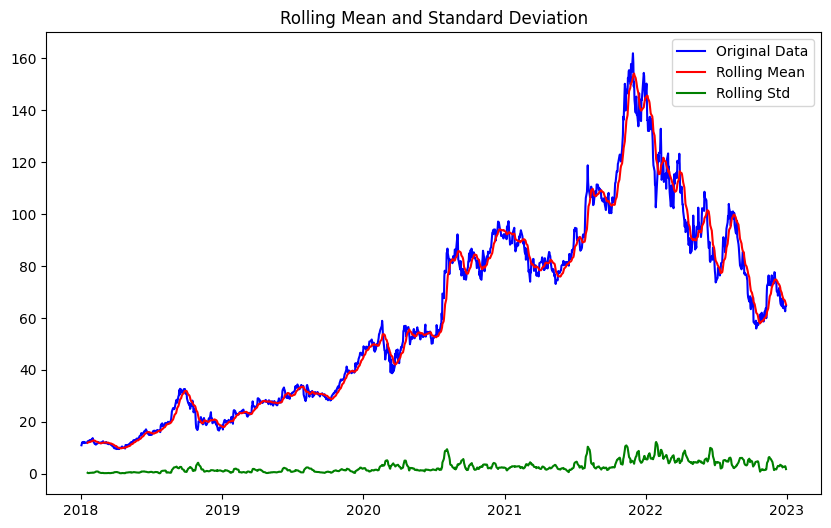

ADF Statistic: -1.5123089718763858
p-value: 0.5274137169931014
Critical Values:
1%: -3.4355629707955395
5%: -2.863842063387667
10%: -2.567995644141416
AMZN


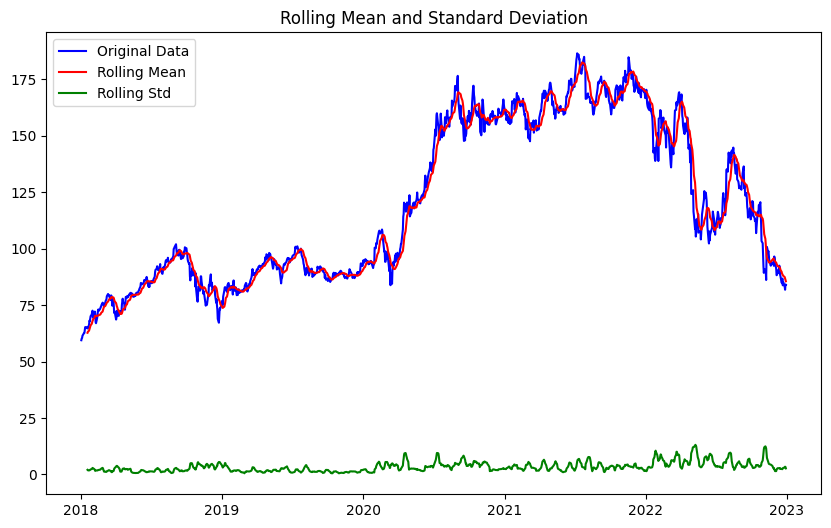

ADF Statistic: -1.7054380039010957
p-value: 0.42831285416183396
Critical Values:
1%: -3.4355588184378574
5%: -2.8638402312881497
10%: -2.5679946684494275
F


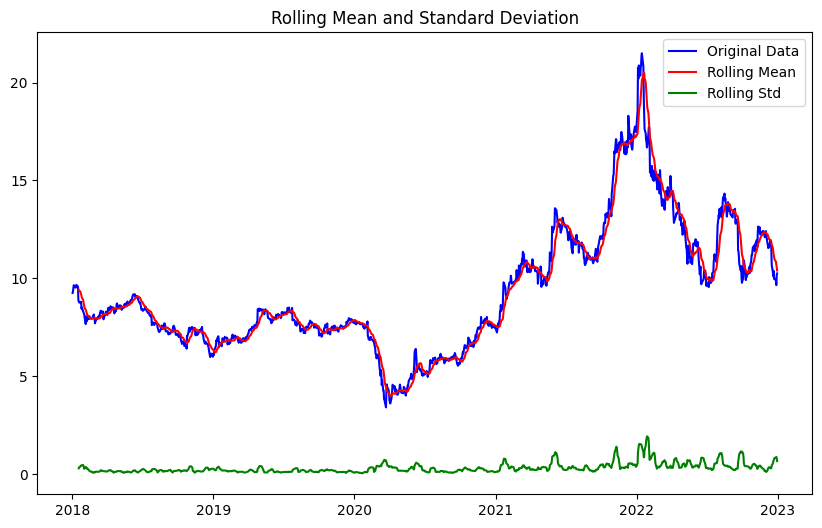

ADF Statistic: -1.4385549354445606
p-value: 0.5636592810739024
Critical Values:
1%: -3.4355588184378574
5%: -2.8638402312881497
10%: -2.5679946684494275
GOOG


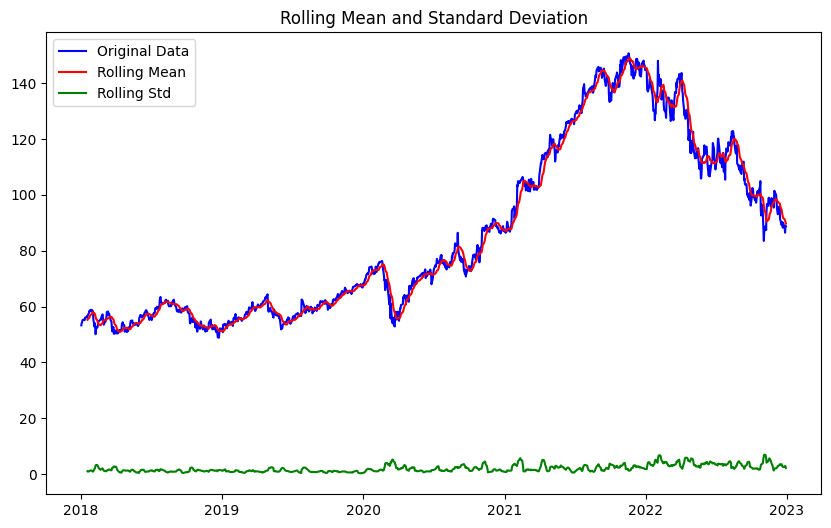

ADF Statistic: -1.2108345267877036
p-value: 0.6689176927500176
Critical Values:
1%: -3.4355629707955395
5%: -2.863842063387667
10%: -2.567995644141416
INTC


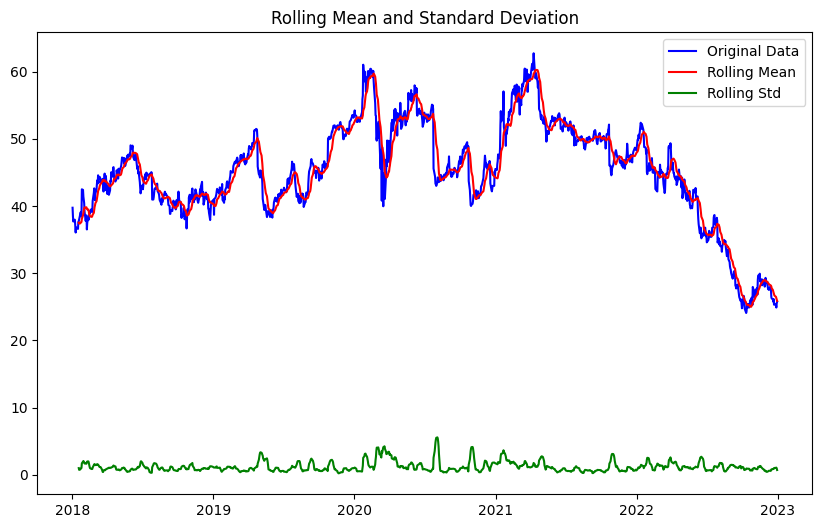

ADF Statistic: -1.6938118341222677
p-value: 0.4343035934088574
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626
JPM


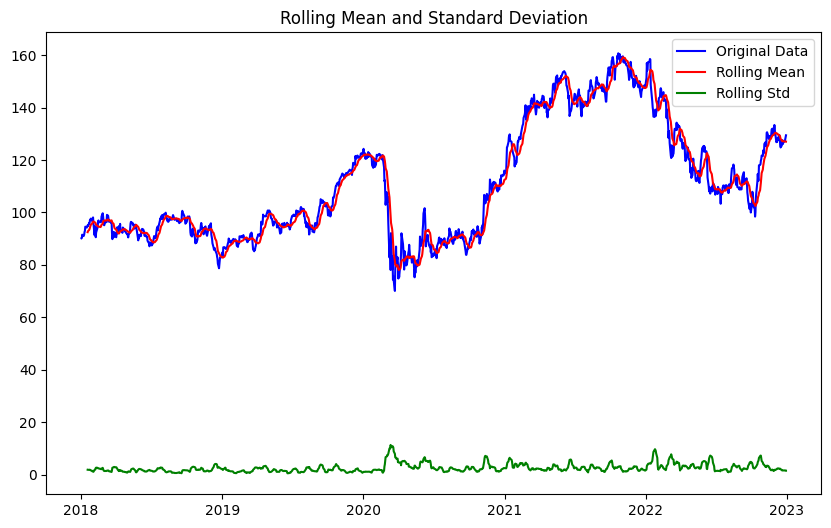

ADF Statistic: -1.4722532485304027
p-value: 0.5471899014440731
Critical Values:
1%: -3.4356133204636095
5%: -2.8638642784217305
10%: -2.5680074748794373
MSFT


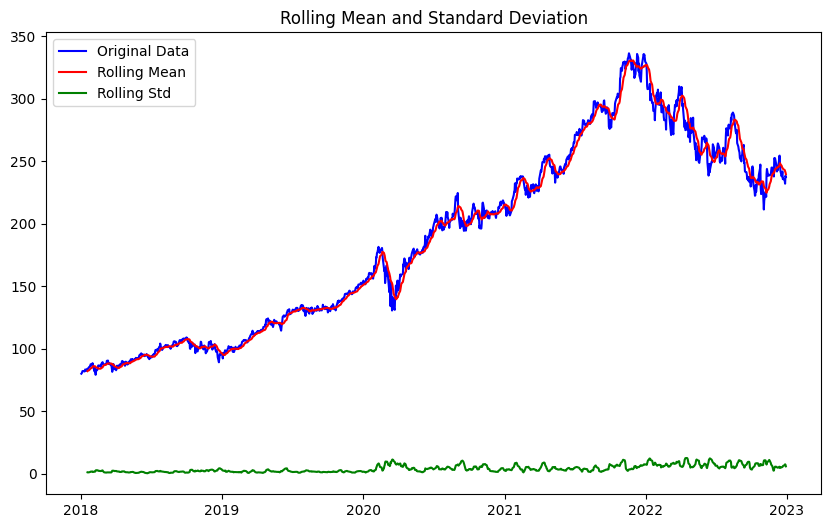

ADF Statistic: -1.2874764129153726
p-value: 0.6348822162892841
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626
MS


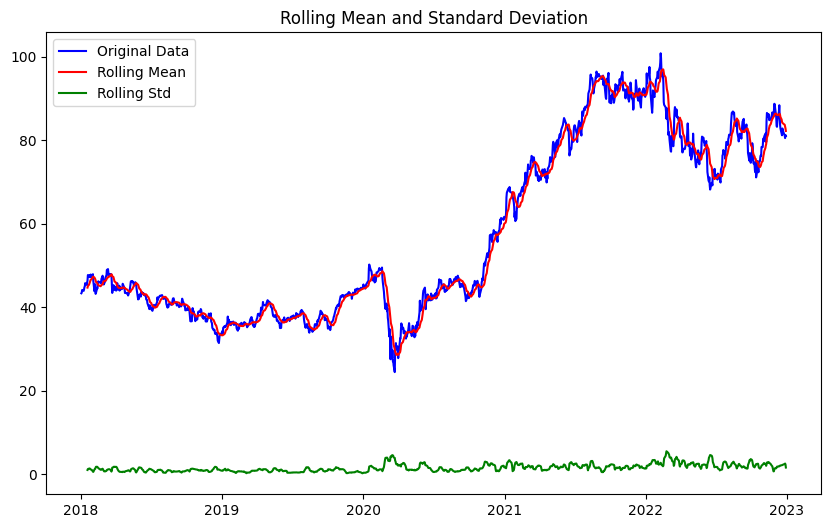

ADF Statistic: -0.7435501775948313
p-value: 0.8351443626372537
Critical Values:
1%: -3.435592223709696
5%: -2.8638549702604803
10%: -2.56800251776
NVDA


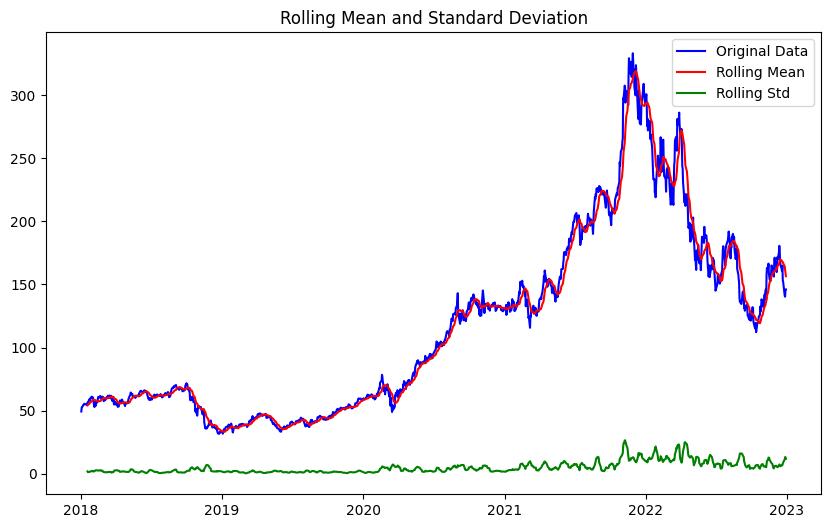

ADF Statistic: -1.1888753185998717
p-value: 0.6783628678327055
Critical Values:
1%: -3.435630320520318
5%: -2.863871779019612
10%: -2.56801146937726
TSLA


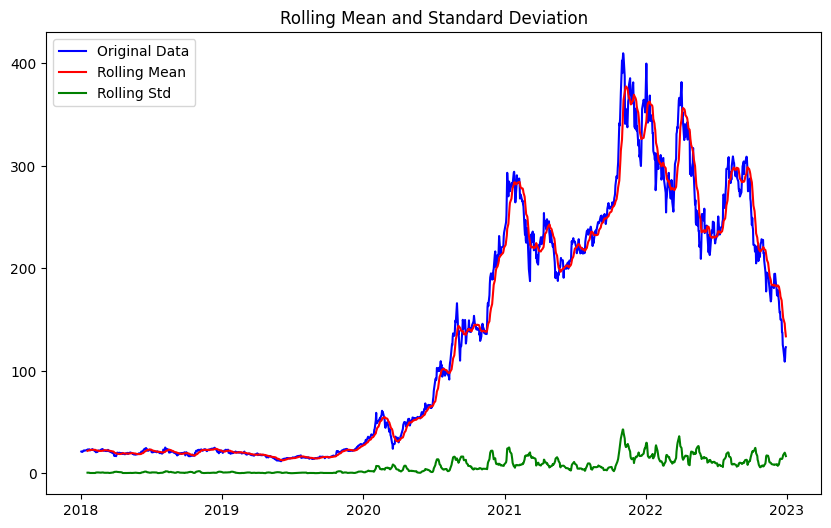

ADF Statistic: -1.301075667011038
p-value: 0.6286800511343598
Critical Values:
1%: -3.435634587707382
5%: -2.8638736617392837
10%: -2.568012472034339
VOO


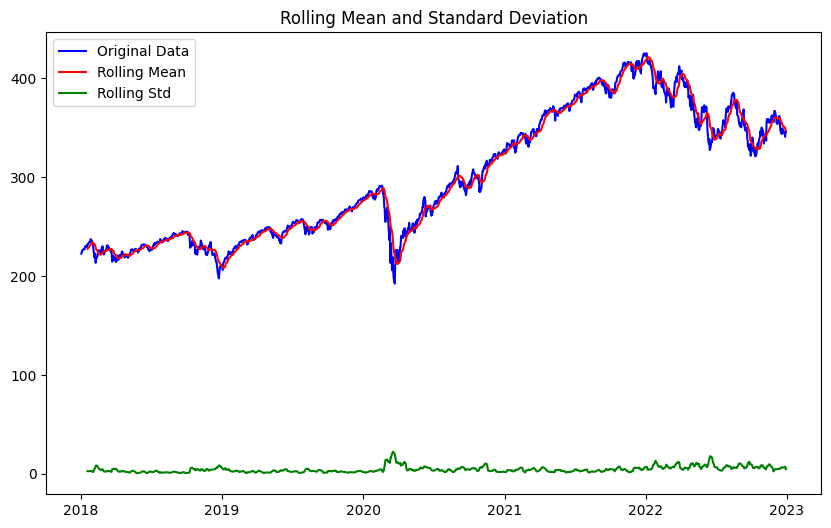

ADF Statistic: -1.1490807366527296
p-value: 0.6951077718585852
Critical Values:
1%: -3.4356006420838963
5%: -2.8638586845641063
10%: -2.5680044958343604


In [176]:
# Performing the Augmented Dickey–Fuller (ADF) test on each stock’s time series to check for stationarity.
# This step ensures the series meet ARIMA model assumptions before forecasting.
models = []
for col in train_df.columns:
    print(col)
    adj_closed = train_df[col]
    arima = MyARIMA(adj_closed)
    models.append((arima, col))
    arima.check_stationarity(adj_closed)


In [177]:
# Defining a dictionary that specifies which stocks should be log-transformed before ARIMA modeling.
# Log transformation helps stabilize variance for highly volatile stocks, improving ARIMA performance.
convert_log = {'AAPL' : True,'AMD' : True,'AMZN': False,'F': True,'GOOG' : False,'INTC':False,'JPM':False,'MSFT':False, 'MS': True,
               'NVDA':True, 'TSLA':True,'VOO':False}


AAPL


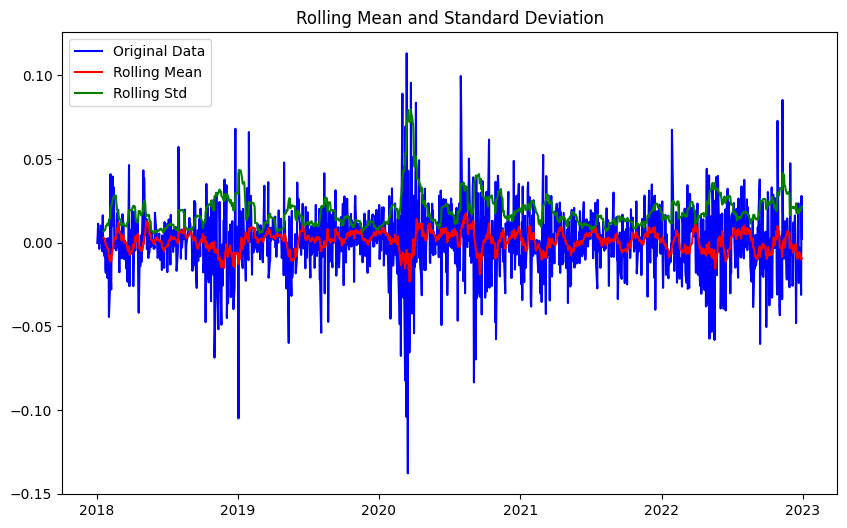

ADF Statistic: -11.071302356820977
p-value: 4.546352997699408e-20
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626


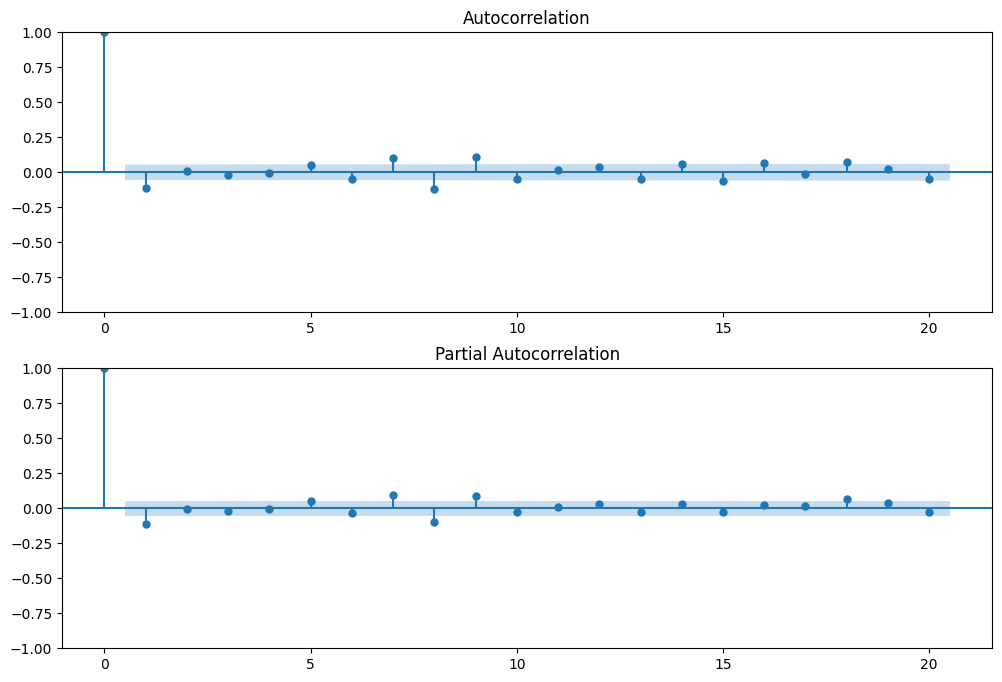

AMD


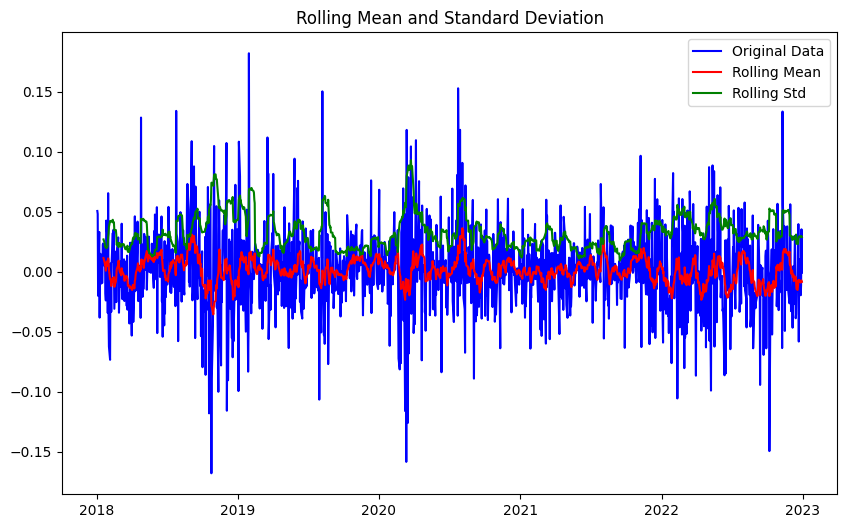

ADF Statistic: -21.302089654318884
p-value: 0.0
Critical Values:
1%: -3.435571295403709
5%: -2.863845736356174
10%: -2.567997600196822


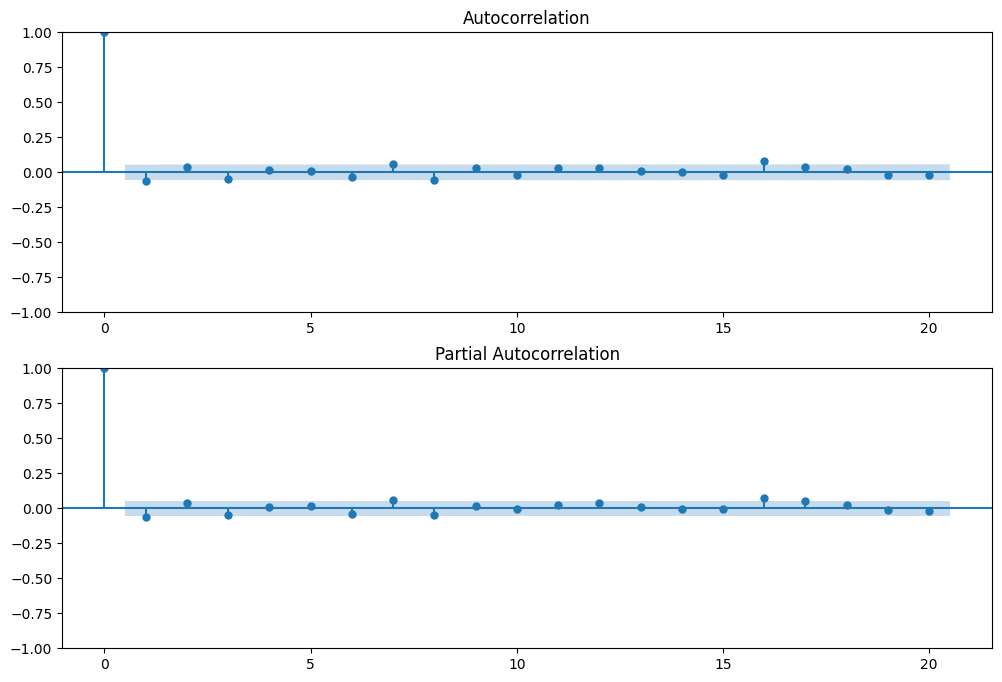

AMZN


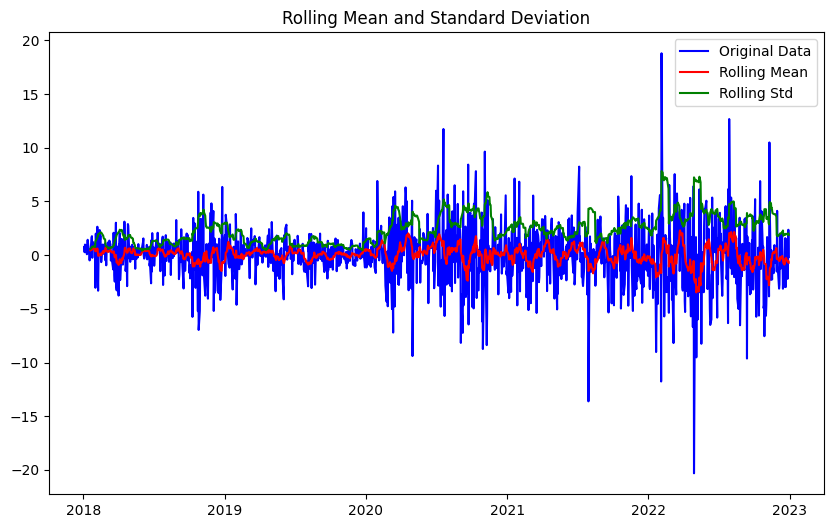

ADF Statistic: -36.13716788912932
p-value: 0.0
Critical Values:
1%: -3.4355629707955395
5%: -2.863842063387667
10%: -2.567995644141416


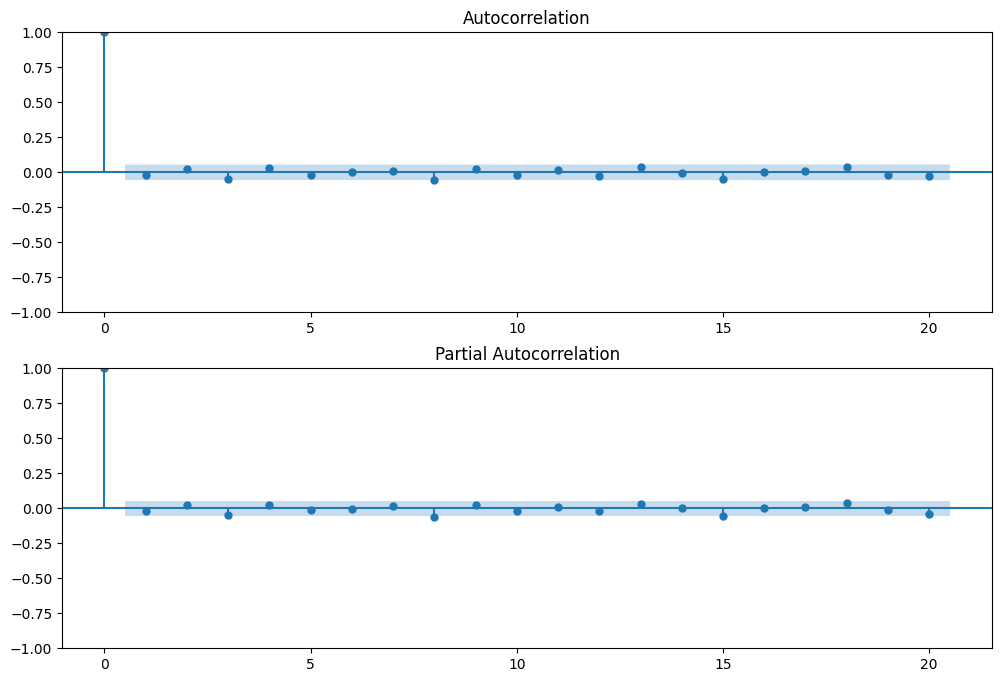

F


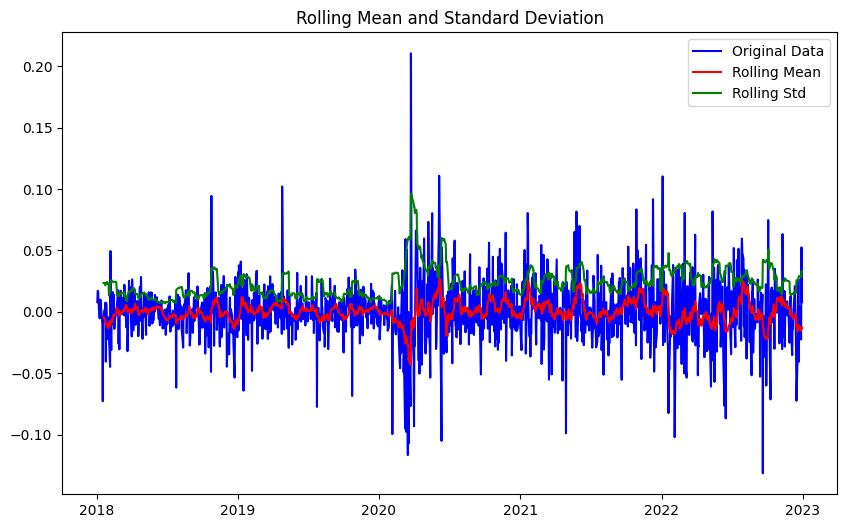

ADF Statistic: -10.888775095221437
p-value: 1.2404053268585492e-19
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626


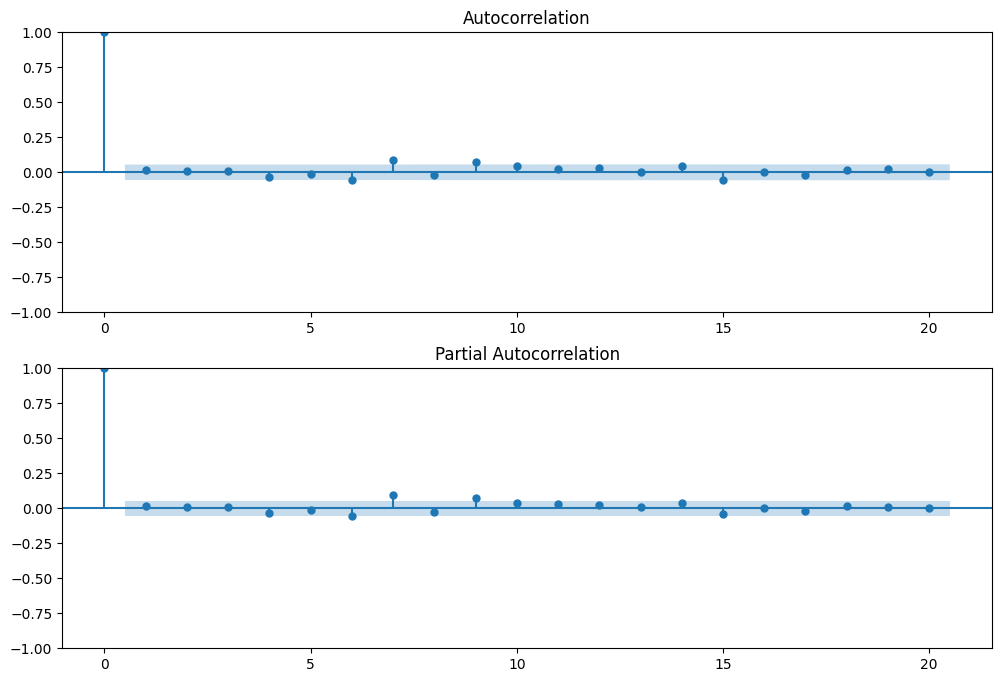

GOOG


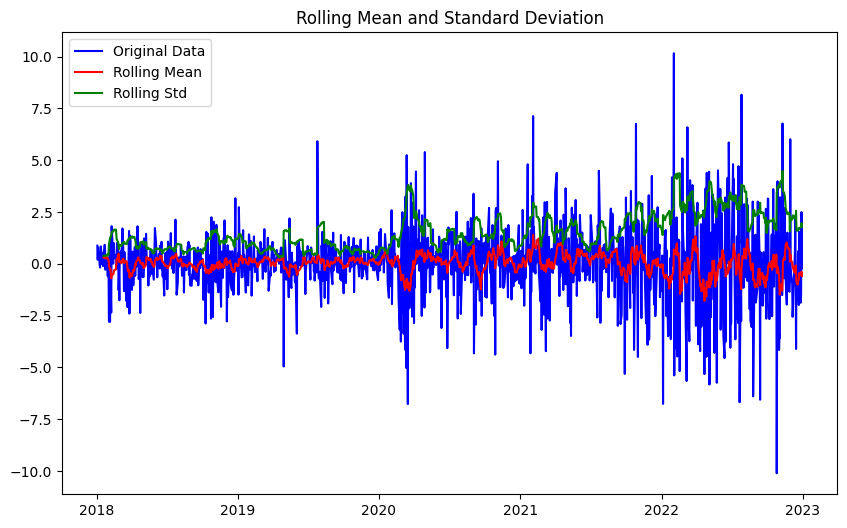

ADF Statistic: -37.7396110973246
p-value: 0.0
Critical Values:
1%: -3.4355629707955395
5%: -2.863842063387667
10%: -2.567995644141416


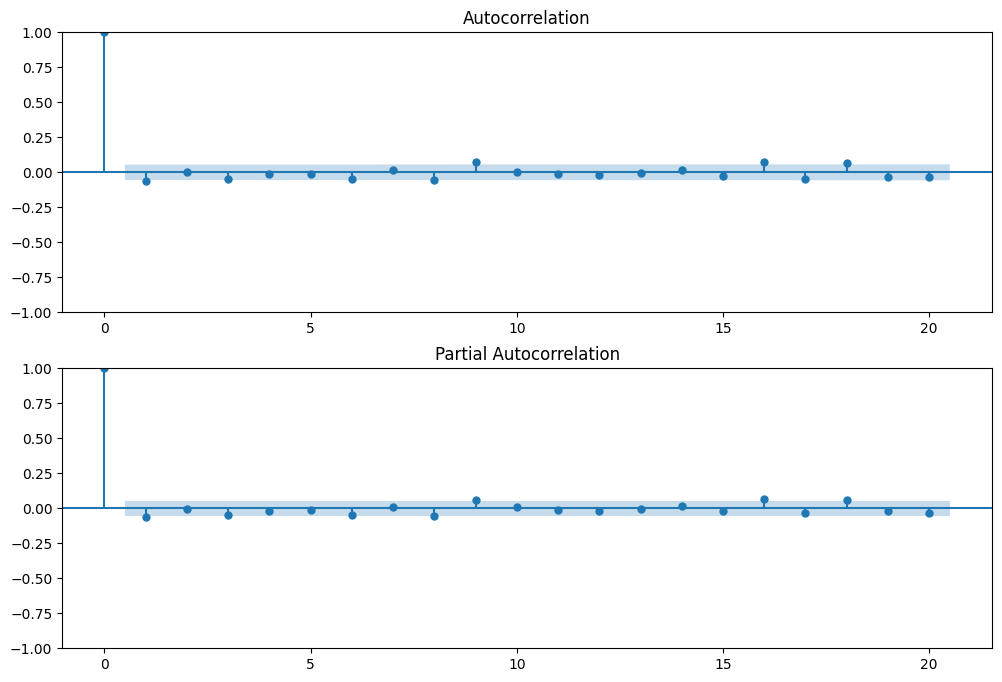

INTC


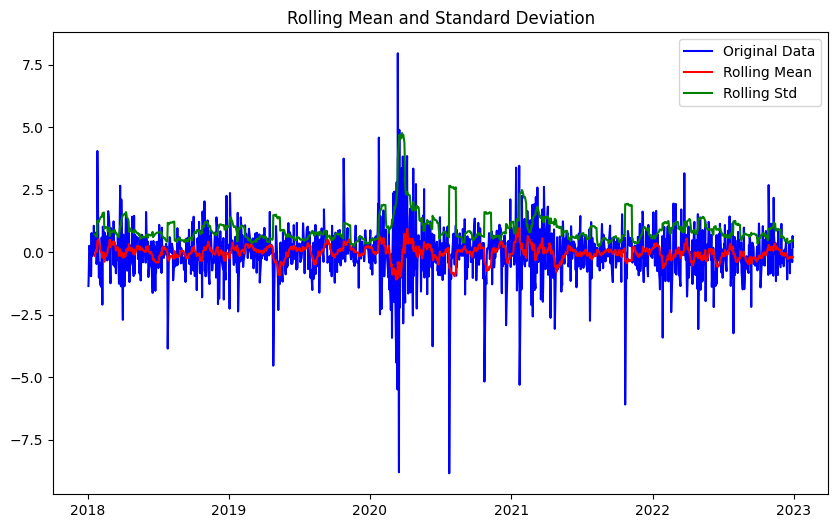

ADF Statistic: -11.733274484897064
p-value: 1.3260038850279013e-21
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626


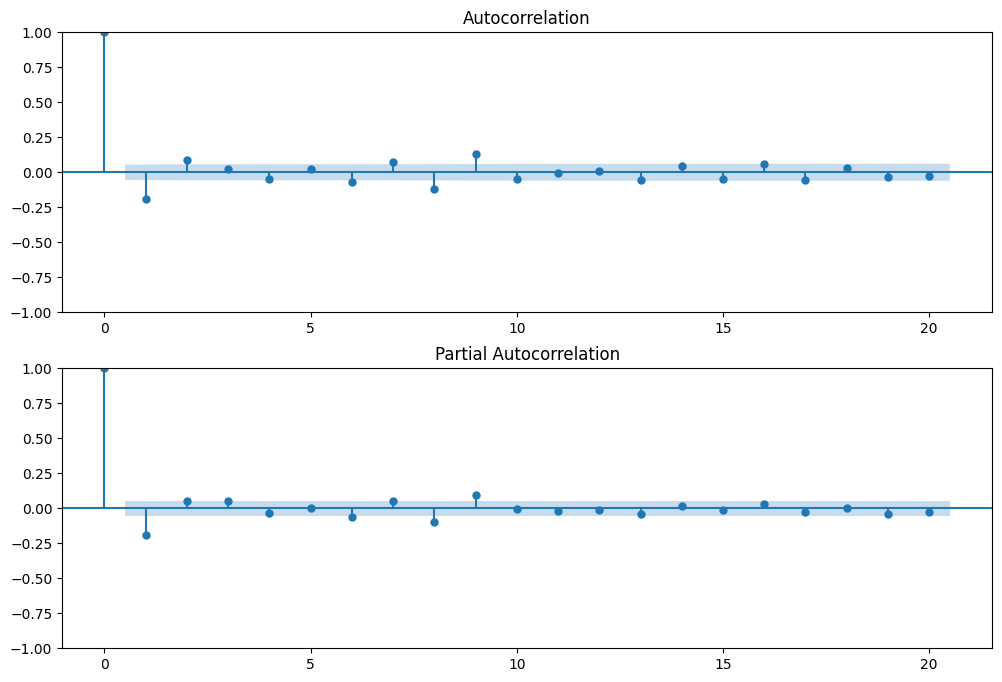

JPM


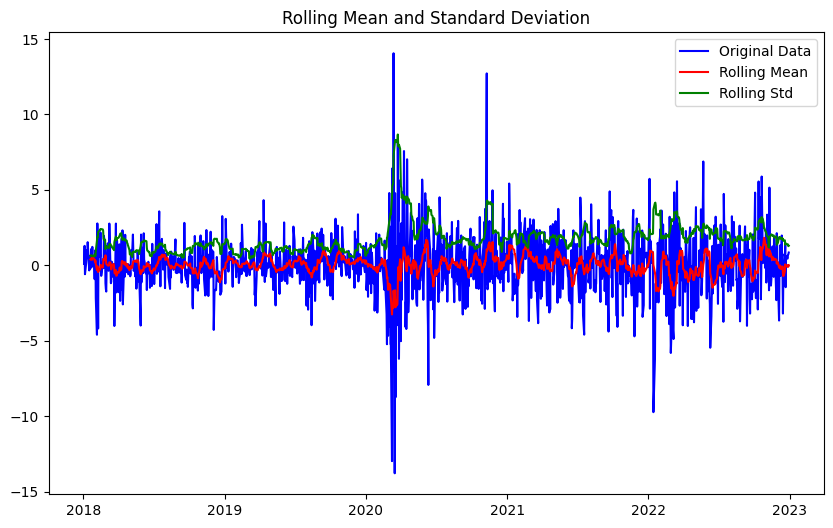

ADF Statistic: -10.61221670620689
p-value: 5.794739398928471e-19
Critical Values:
1%: -3.4356133204636095
5%: -2.8638642784217305
10%: -2.5680074748794373


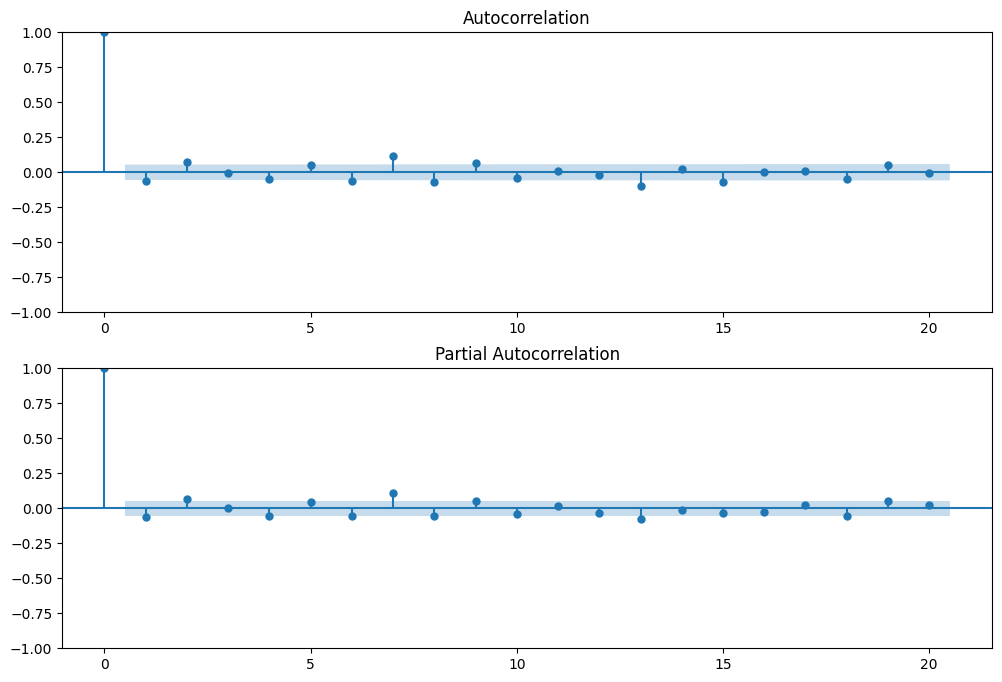

MSFT


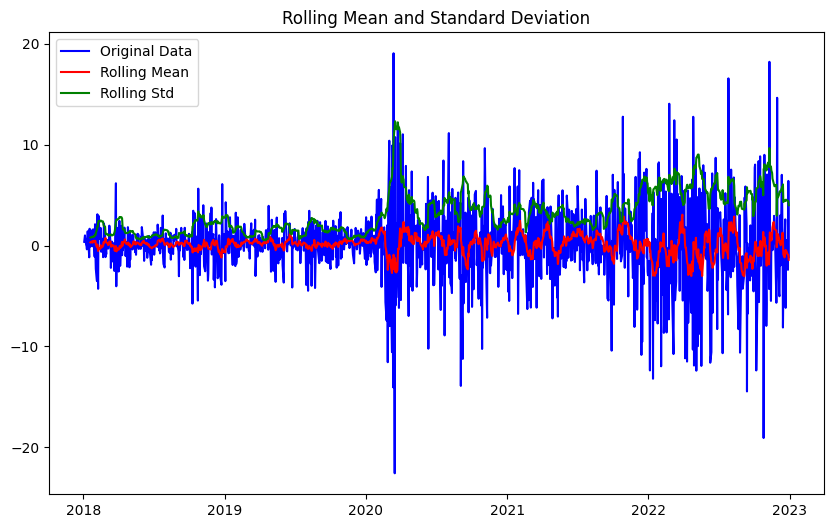

ADF Statistic: -11.984447140561093
p-value: 3.6406990866820105e-22
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626


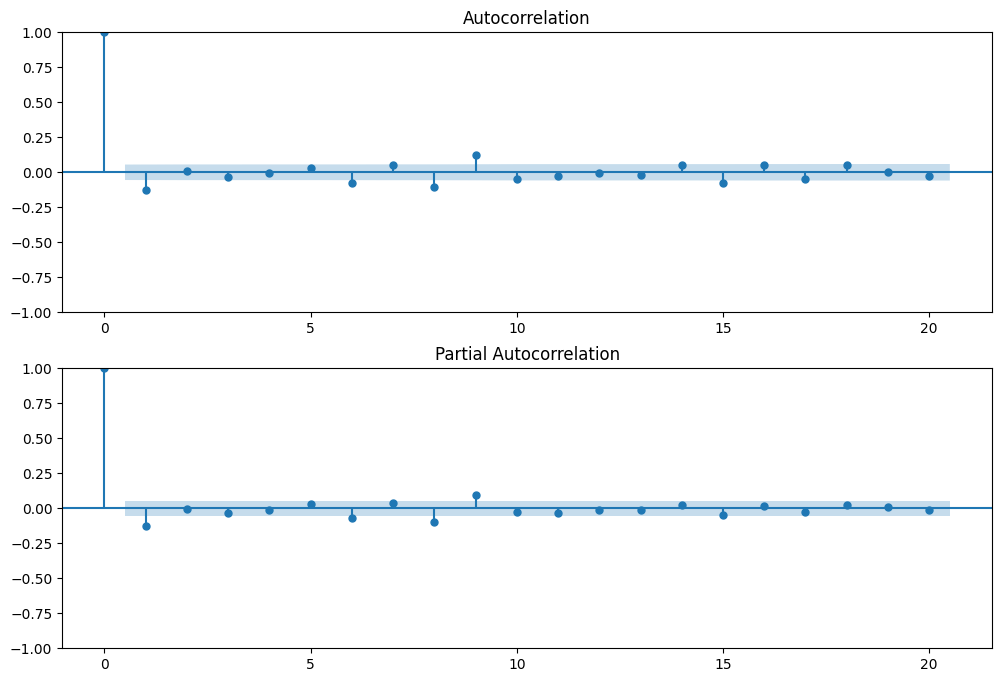

MS


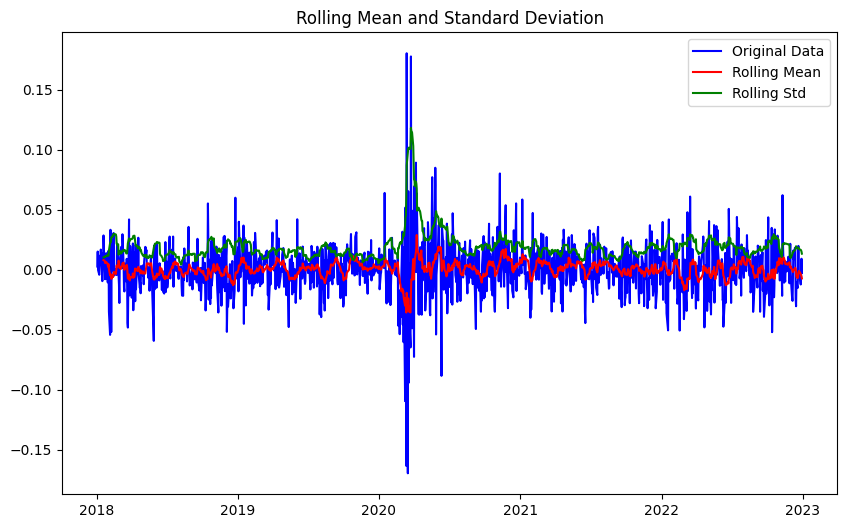

ADF Statistic: -10.83781459412432
p-value: 1.644885324354047e-19
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626


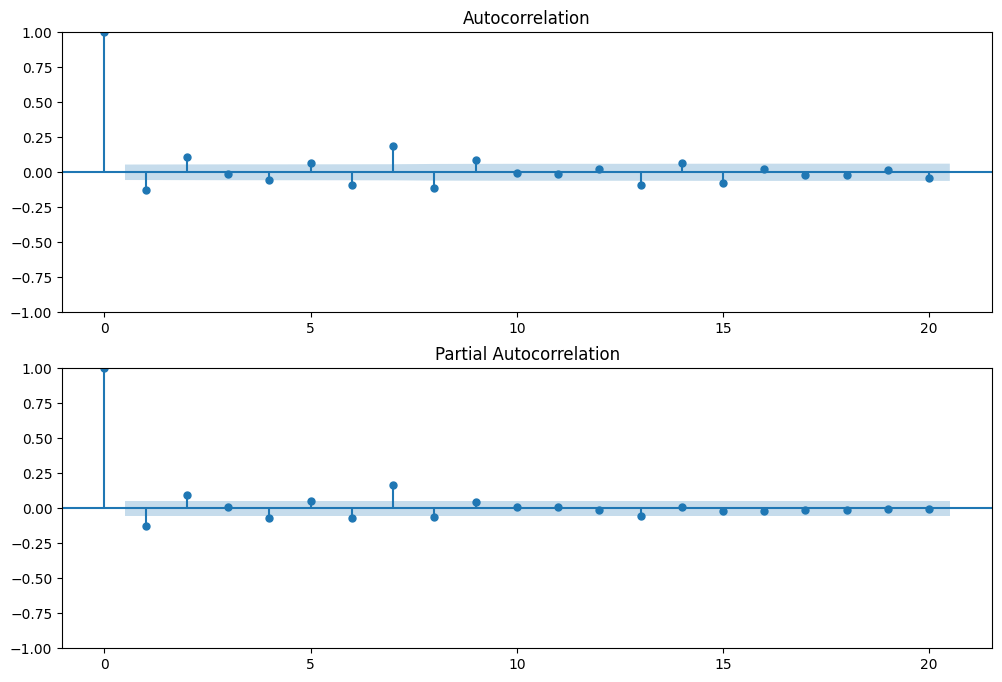

NVDA


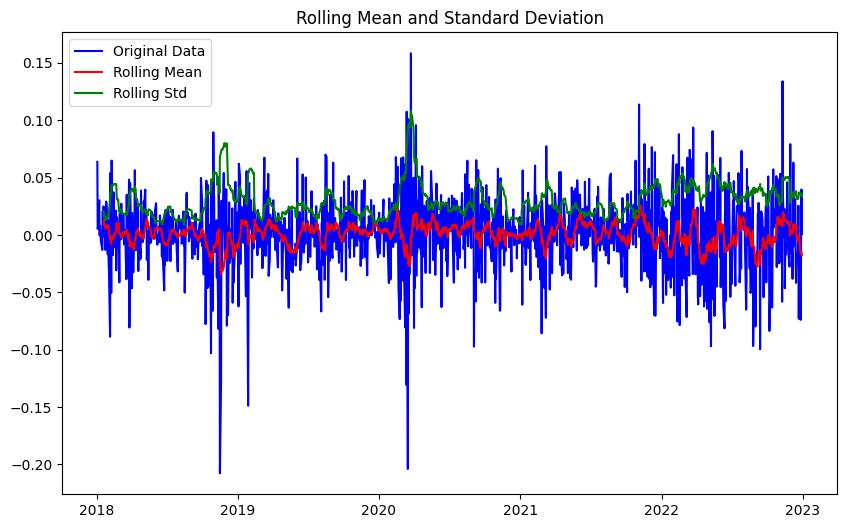

ADF Statistic: -11.585536043262334
p-value: 2.873648731174857e-21
Critical Values:
1%: -3.4355964295197743
5%: -2.863856825923603
10%: -2.5680035060041626


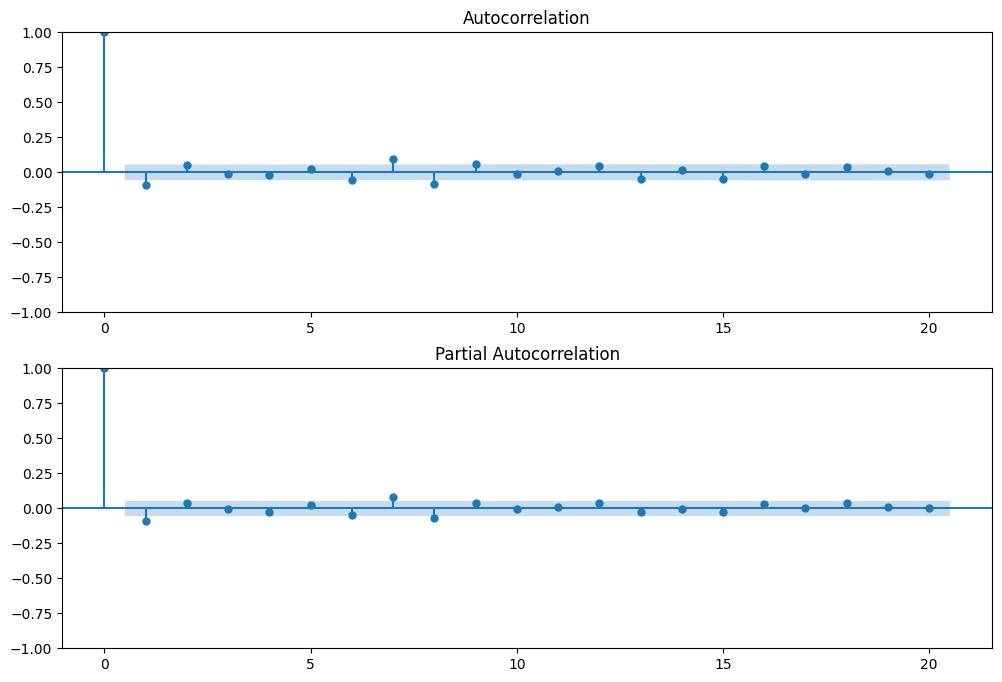

TSLA


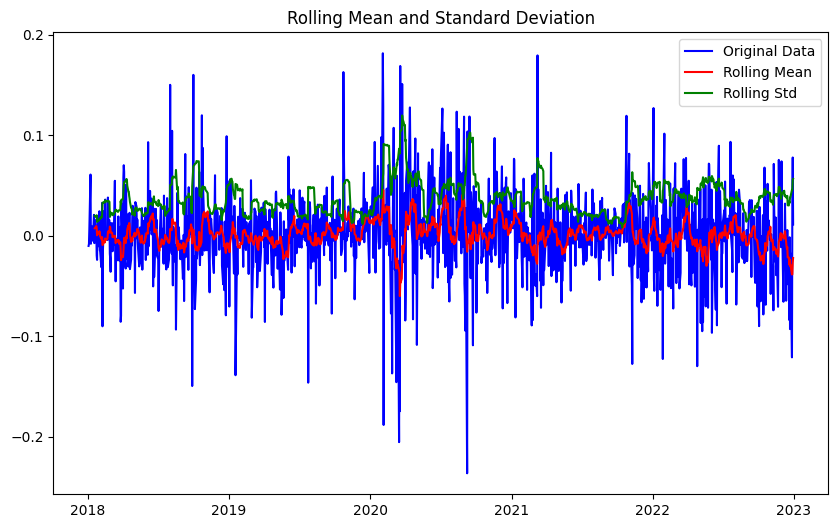

ADF Statistic: -24.14835034370218
p-value: 0.0
Critical Values:
1%: -3.4355671297788666
5%: -2.8638438984080117
10%: -2.5679966213893057


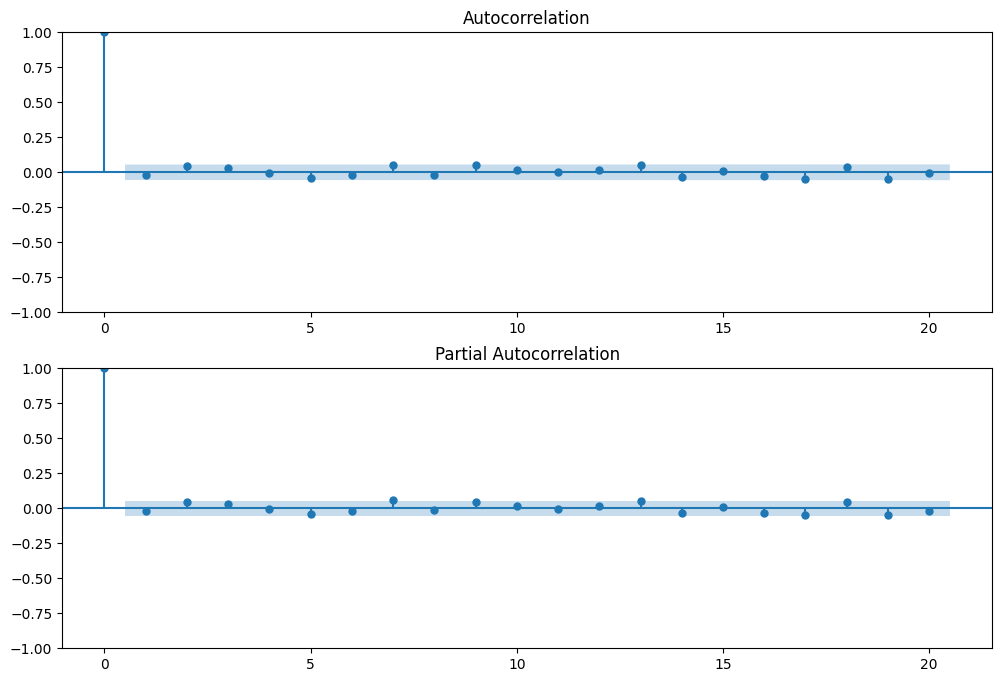

VOO


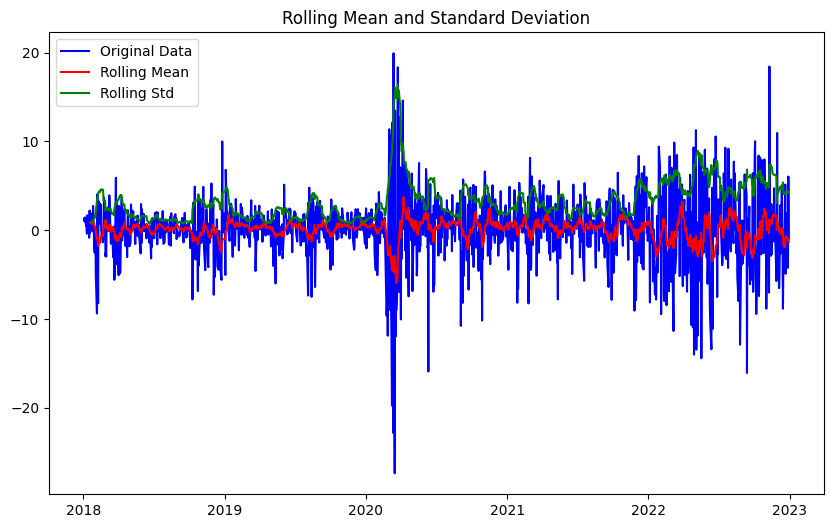

ADF Statistic: -11.031997915604247
p-value: 5.637734930280099e-20
Critical Values:
1%: -3.4356006420838963
5%: -2.8638586845641063
10%: -2.5680044958343604


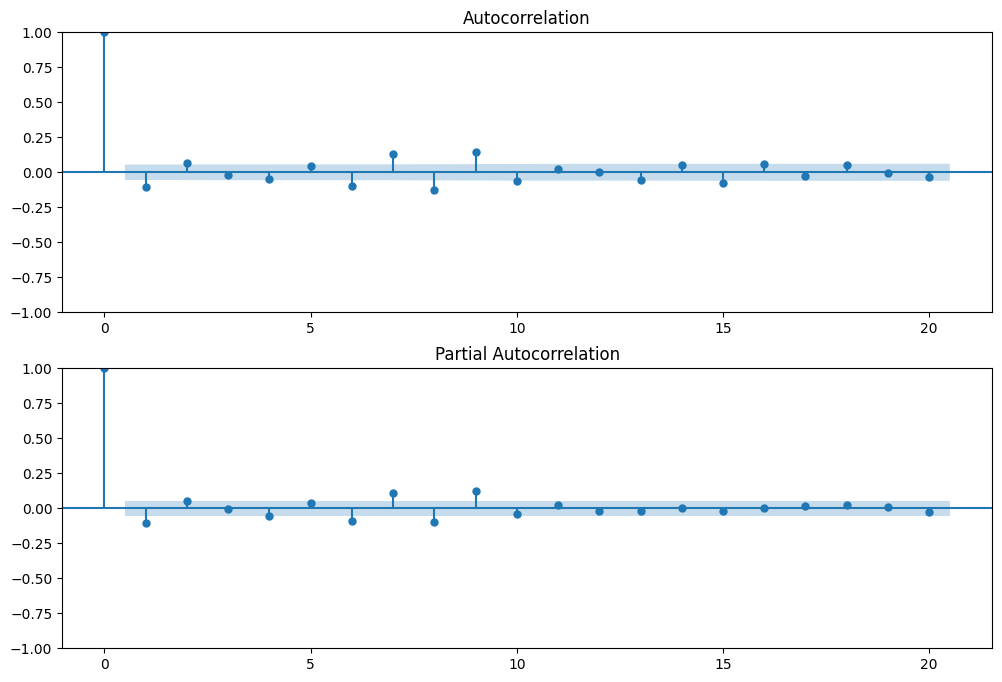

In [178]:
# Applying log transformation (where required) and differencing to make each stock’s time series stationary before ARIMA modeling.
# This block checks stationarity again and generates ACF/PACF plots to guide optimal ARIMA order selection.
shift = 1
for arima, col in models:
    print(col)
    data = arima.time_series_data
    if convert_log[col]:
        data = arima.log_data(data)
    diff_data = arima.difference_data(data, shift)[1:]
    arima.check_stationarity(diff_data)
    arima.acf_pacf_plots(diff_data)


In [179]:
# Fitting ARIMA models and generating out-of-sample forecasts for each stock, applying inverse log-transform where needed.
# The predicted values are stored in a new dataframe aligned with the test period for future performance evaluation.
forecasted_data = test_df.copy()
N = len(forecasted_data)
for arima, col in models:
    print(col)
    data = arima.time_series_data
    if convert_log[col]:
        data = arima.log_data(data)
    arima.fit_arima_parameters(data)
    if convert_log[col]:
        forecasted_data[col] = np.exp(arima.forecast(data, N))
    else:
        forecasted_data[col] = arima.forecast(data, N)


AAPL
AMD
AMZN
F
GOOG
INTC
JPM
MSFT
MS
NVDA
TSLA
VOO


In [180]:
# Initializing the Modern Portfolio Theory (MPT) optimizer and extracting the list of asset names for portfolio construction.
# This prepares the optimizer to generate optimal weights based on the test dataset's assets.
mpt = MPTOptimizer()
l = list(test_df.columns)


In [181]:
# Optimizing portfolio weights using the ARIMA-forecasted returns and displaying the resulting asset allocation.
# This step applies Modern Portfolio Theory to derive weights that balance risk and return based on predicted performance.
arima_allocs = mpt.optimize_portfolio(forecasted_data)
print("Forecasted Data Allocation")
for val, ticker in zip(arima_allocs, l):
    print(ticker + ": " + str(round(val,3)))


Forecasted Data Allocation
AAPL: 0.0
AMD: 0.0
AMZN: 0.0
F: 0.0
GOOG: 0.946
INTC: 0.0
JPM: 0.0
MSFT: 0.0
MS: 0.013
NVDA: 0.041
TSLA: 0.0
VOO: 0.0


In [182]:
# Running the MPT optimizer on historical training data to compute baseline (non-forecast) portfolio weights.
# This allows comparison between allocations derived from actual past data and those generated from ARIMA forecasts.
mpt_allocs = mpt.optimize_portfolio(train_df)
print("MyOptimizer's Data Allocation")
for val, ticker in zip(mpt_allocs, l):
    print(ticker + ": " + str(round(val,3)))


MyOptimizer's Data Allocation
AAPL: 0.0
AMD: 0.575
AMZN: 0.0
F: 0.0
GOOG: 0.0
INTC: 0.0
JPM: 0.0
MSFT: 0.0
MS: 0.0
NVDA: 0.0
TSLA: 0.425
VOO: 0.0


In [183]:
# Computing key performance metrics (Sharpe, Treynor, Beta, Alpha) for the ARIMA-based portfolio using utility functions.
# This evaluates the risk-adjusted returns and systematic risk of the forecast-optimized portfolio relative to the market index.
mean_arima, std_arima, cr_arima, sr_arima = utils.sharpe_ratio_metrics(test_df,arima_allocs)
treynor_arima,beta_arima,alpha_arima = utils.treynor_ratio_metrics(test_df,arima_allocs,index_data)
print("ARIMA Metrics")
print("Mean: " + str(mean_arima))
print("Std Dev: " + str(std_arima))
print("Calculated Risk: " + str(cr_arima))
print("Sharpe Ratio: " + str(sr_arima))
print("Treynor Ratio: " + str(treynor_arima))
print("Beta: " + str(beta_arima))
print("Alpha: " + str(alpha_arima))


ARIMA Metrics
Mean: 0.0022769469919502235
Std Dev: 0.018685237583515313
Calculated Risk: 0.6871599909087123
Sharpe Ratio: 1.9344368929485738
Treynor Ratio: 0.0014095699398007195
Beta: 1.4770086486411322
Alpha: 0.0008220987553235165


In [184]:
# Evaluating the historical-data MPT portfolio using Sharpe, Treynor, Beta, and Alpha to benchmark risk-adjusted performance.
# This allows direct comparison between traditional MPT allocations and ARIMA-driven allocations.
mean_mpt, std_mpt, cr_mpt, sr_mpt = utils.sharpe_ratio_metrics(test_df, mpt_allocs)
treynor_mpt, beta_mpt, alpha_mpt = utils.treynor_ratio_metrics(test_df, mpt_allocs, index_data)

print("MyOptimizer Metrics")
print("Mean: " + str(mean_mpt))
print("Std Dev: " + str(std_mpt))
print("Calculated Risk: " + str(cr_mpt))
print("Sharpe Ratio: " + str(sr_mpt))
print("Treynor Ratio: " + str(treynor_mpt))
print("Beta: " + str(beta_mpt))
print("Alpha: " + str(alpha_mpt))


MyOptimizer Metrics
Mean: 0.003703578088918857
Std Dev: 0.026665309842949757
Calculated Risk: 1.3003698380802708
Sharpe Ratio: 2.204830165206857
Treynor Ratio: 0.001668231917767771
Beta: 2.1031716582989355
Alpha: 0.0016319615271509036


In [185]:
# Defining a fixed allocation vector based on K-Means clustering results, assigning equal weight to the three selected cluster representatives.
# This portfolio invests only in the cluster‐recommended stocks while setting all other asset weights to zero.
kmeans_allocs = [0,0,0,0,0,0,1.0/3,0,0,1.0/3,0,1.0/3]


In [186]:
# Evaluating the K-Means–based portfolio by computing its Sharpe, Treynor, Beta, and Alpha metrics.
# This assesses how the clustering-selected assets perform in terms of risk-adjusted returns compared to other strategies.
mean_kmeans, std_kmeans, cr_kmeans, sr_kmeans = utils.sharpe_ratio_metrics(test_df, kmeans_allocs)
treynor_kmeans, beta_kmeans, alpha_kmeans = utils.treynor_ratio_metrics(test_df, kmeans_allocs, index_data)

print("KMeans Metrics")
print("Mean: " + str(mean_kmeans))
print("Std Dev: " + str(std_kmeans))
print("Calculated Risk: " + str(cr_kmeans))
print("Sharpe Ratio: " + str(sr_kmeans))
print("Treynor Ratio: " + str(treynor_kmeans))
print("Beta: " + str(beta_kmeans))
print("Alpha: " + str(alpha_kmeans))


KMeans Metrics
Mean: 0.0024301205188770833
Std Dev: 0.014783100219931046
Calculated Risk: 0.781850563290013
Sharpe Ratio: 2.6095316083410802
Treynor Ratio: 0.0016551490943836425
Beta: 1.3504043390782356
Alpha: 0.0010999770743897988


In [151]:
seq_len = 100
num_epochs = 10000

In [111]:
val_data = train_df.tail(seq_len)

In [112]:
val_data.shape

(100, 12)

In [187]:
# Training LSTM models for all tickers simultaneously to learn sequential patterns in historical price data.
# This step returns the trained models, their loss histories, and the scalers used for normalization.
models, all_loss_tracks, scalars = MyLSTM.fit_all_tickers(train_df, seq_len, num_epochs)


--------------------------------------------------
Fitting model for ticker: AAPL
--------------------------------------------------
Epoch 0/10000, Loss=0.24544310569763184
Epoch 100/10000, Loss=0.16251660883426666
Epoch 200/10000, Loss=0.08871598541736603
Epoch 300/10000, Loss=0.030789338052272797
Epoch 400/10000, Loss=0.0026142275892198086
Epoch 500/10000, Loss=0.0013489257544279099
Epoch 600/10000, Loss=0.0010856217704713345
Epoch 700/10000, Loss=0.0009394361986778677
Epoch 800/10000, Loss=0.0008600245346315205
Epoch 900/10000, Loss=0.0008135586977005005
Epoch 1000/10000, Loss=0.0007813321426510811
Epoch 1100/10000, Loss=0.0007547997520305216
Epoch 1200/10000, Loss=0.0007306826300919056
Epoch 1300/10000, Loss=0.0007079063798300922
Epoch 1400/10000, Loss=0.0006861669826321304
Epoch 1500/10000, Loss=0.0006653841701336205
Epoch 1600/10000, Loss=0.0006455347174778581
Epoch 1700/10000, Loss=0.0006265945849008858
Epoch 1800/10000, Loss=0.0006085383356548846
Epoch 1900/10000, Loss=0.000591

(100, 0)
Evaluating model for ticker: AAPL
100


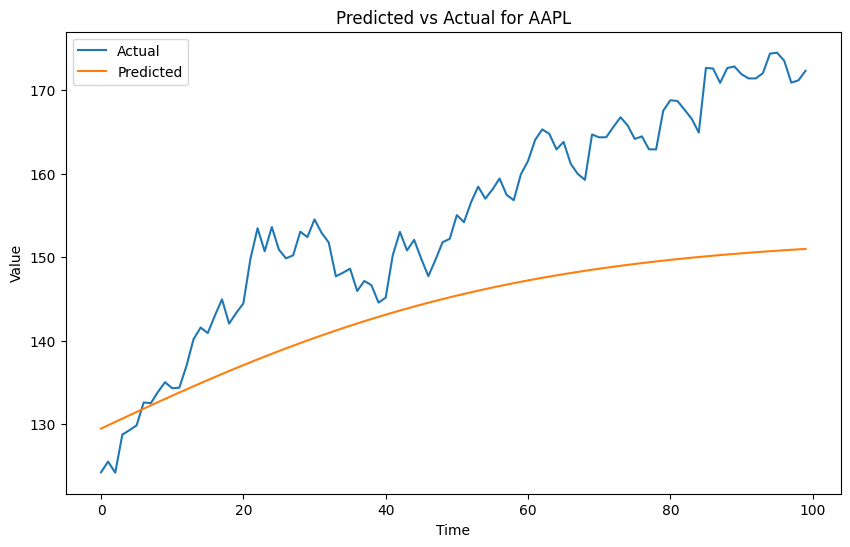

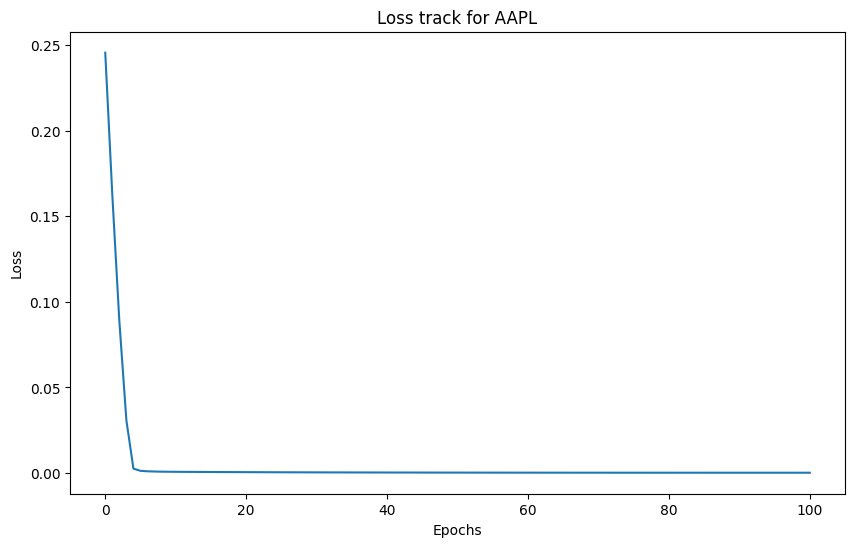

Evaluating model for ticker: AMD
100


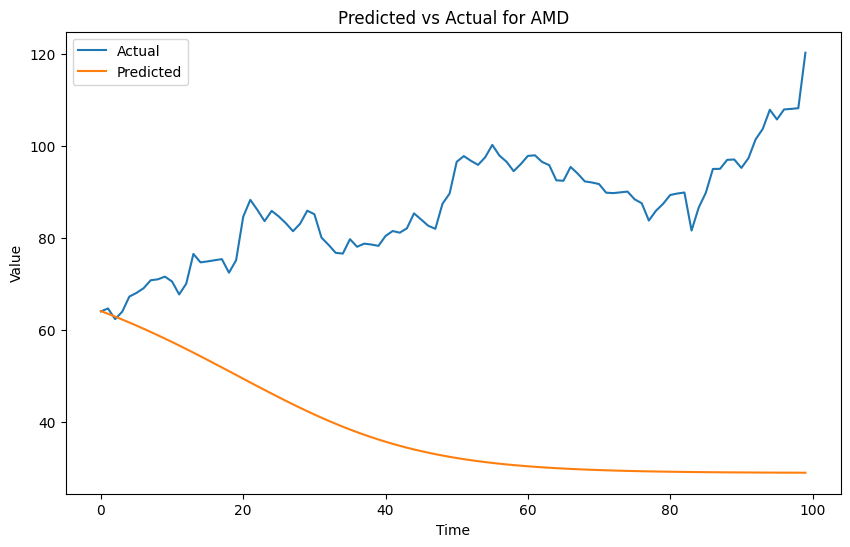

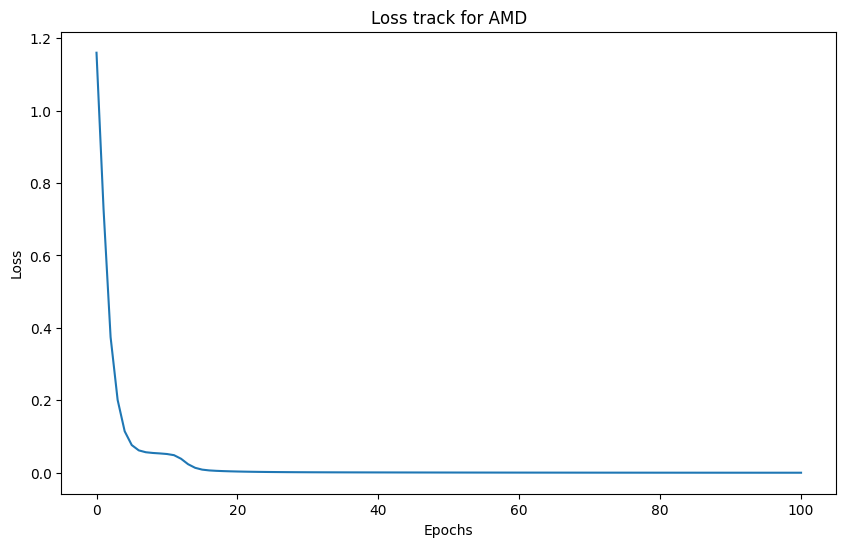

Evaluating model for ticker: AMZN
100


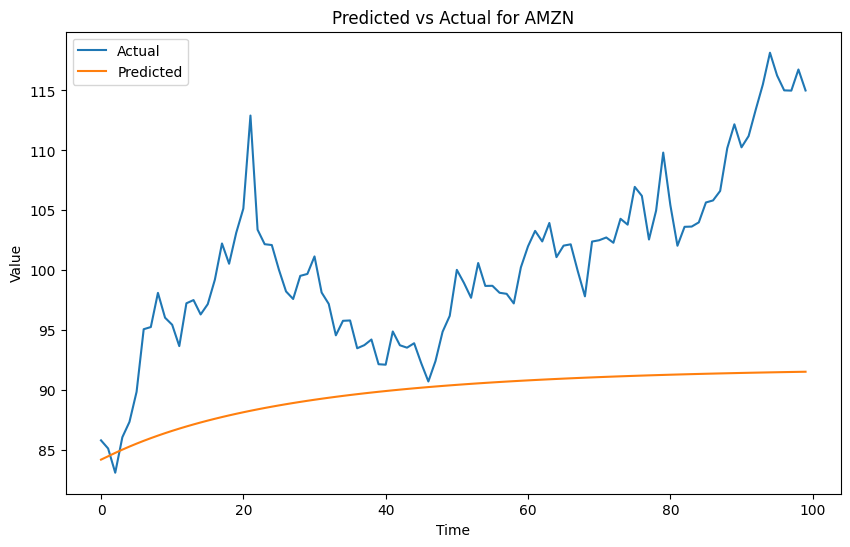

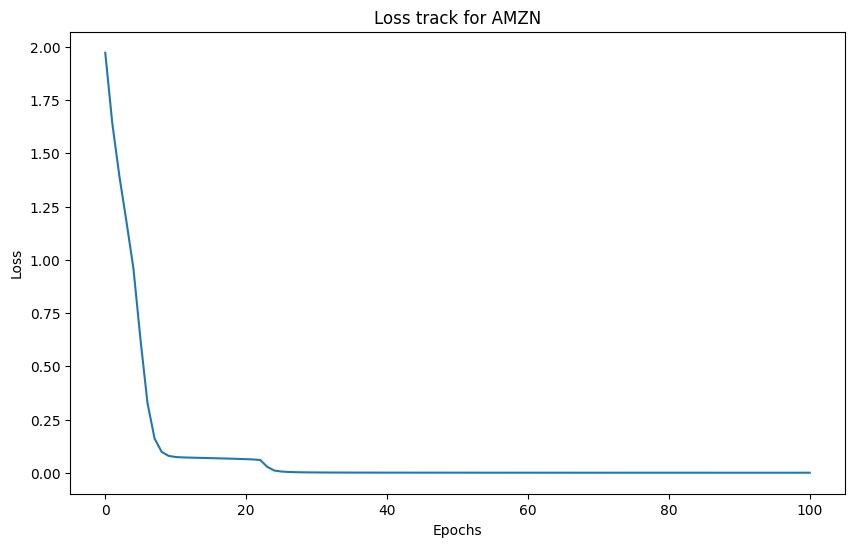

Evaluating model for ticker: F
100


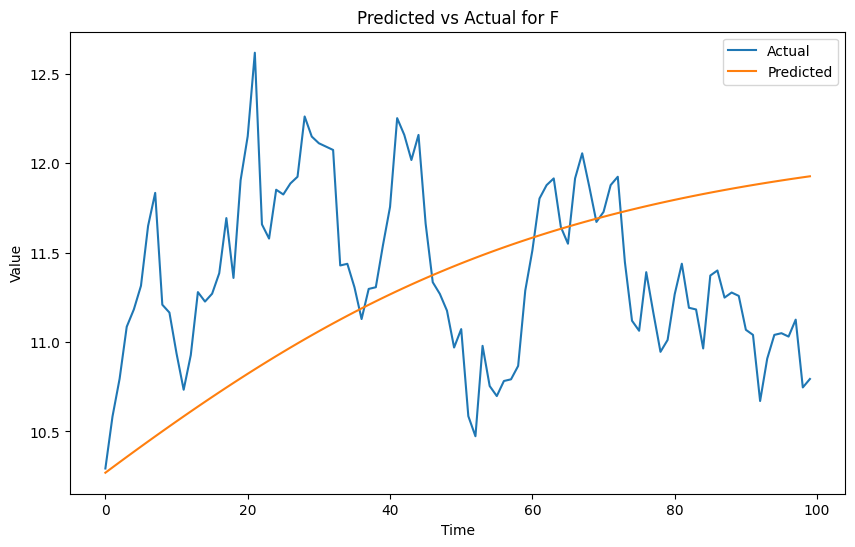

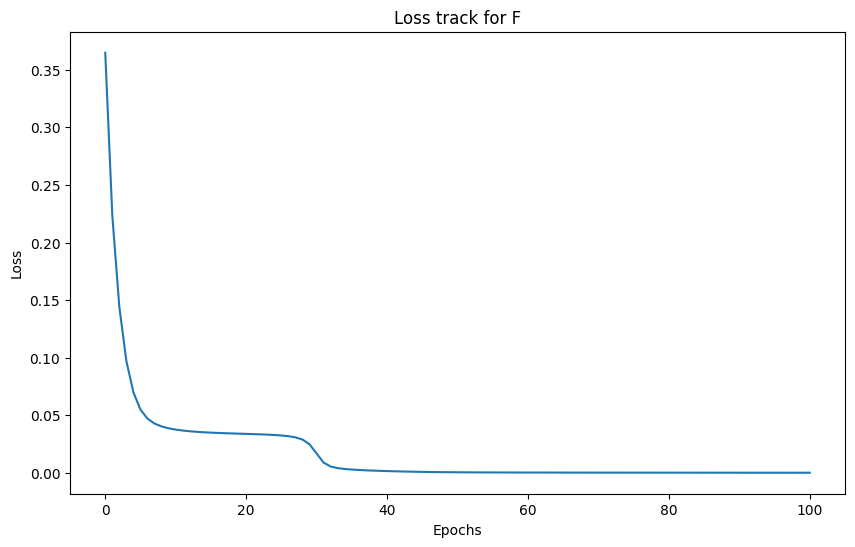

Evaluating model for ticker: GOOG
100


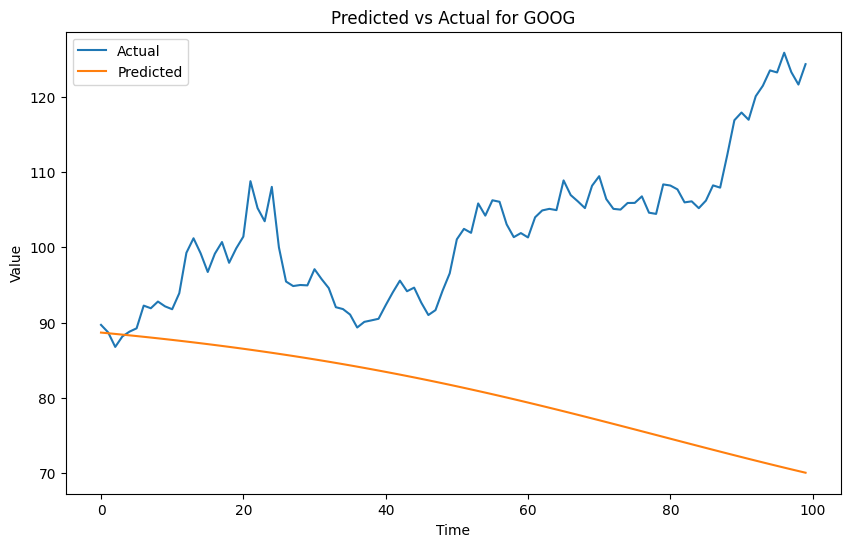

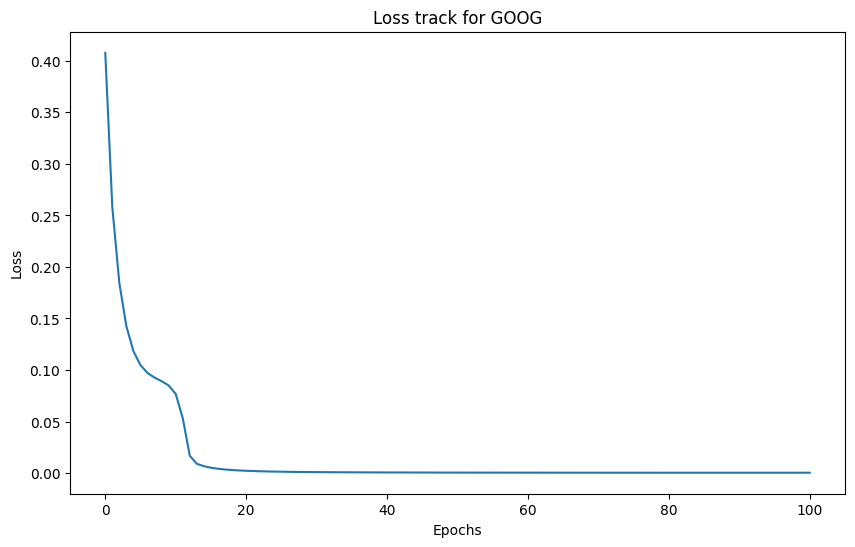

Evaluating model for ticker: INTC
100


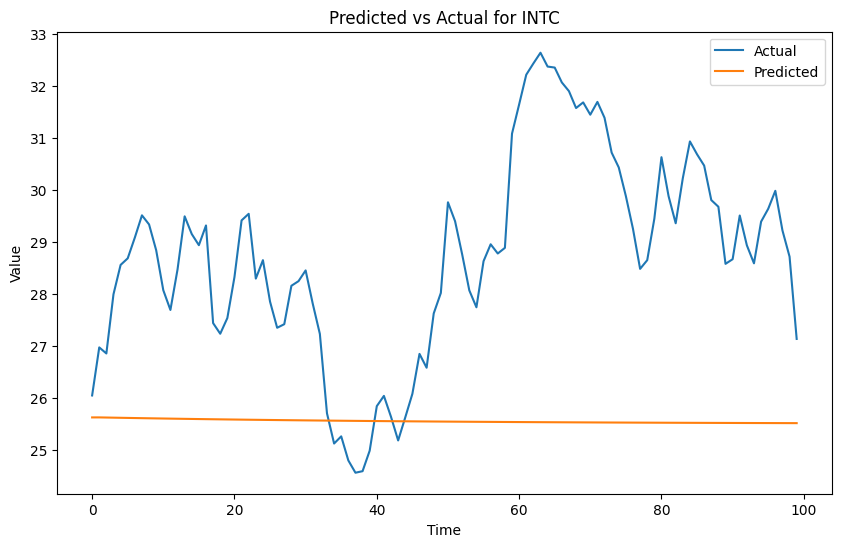

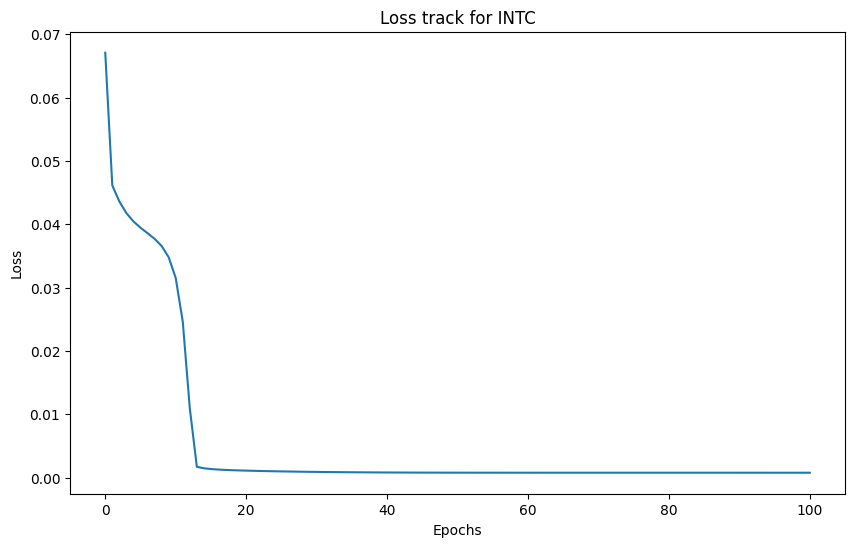

Evaluating model for ticker: JPM
100


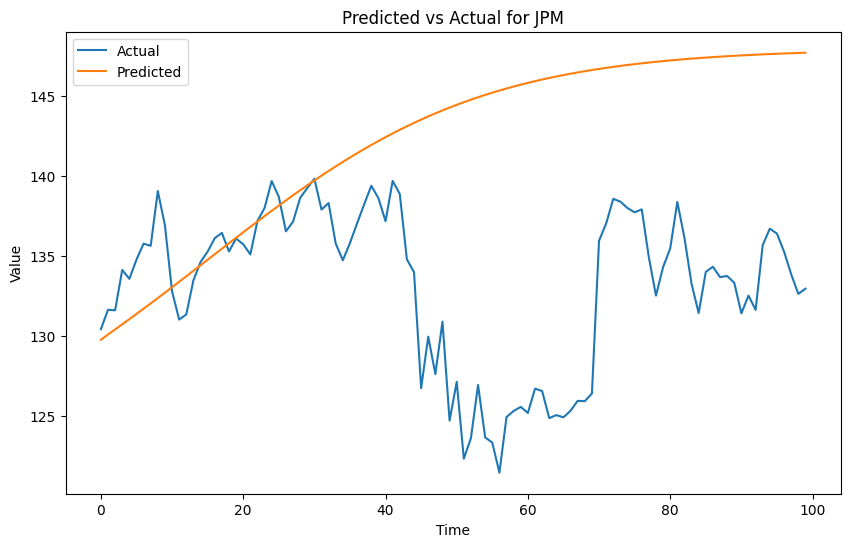

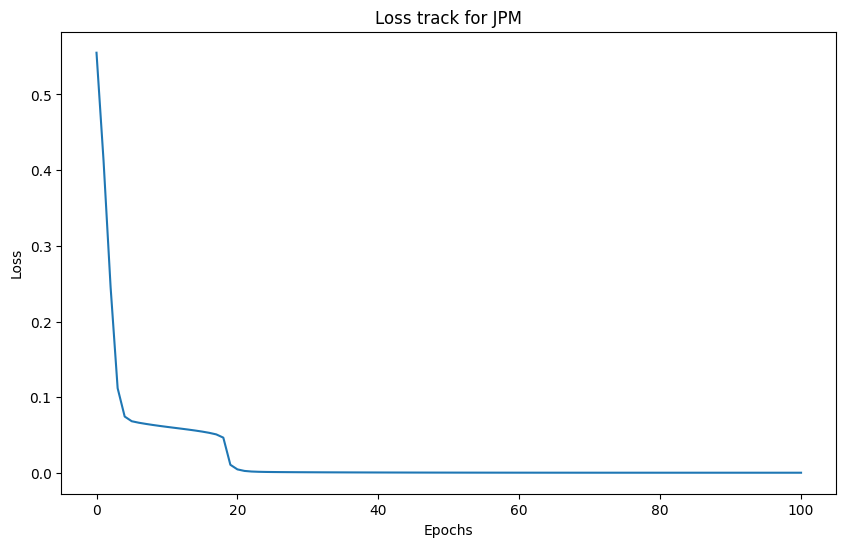

Evaluating model for ticker: MSFT
100


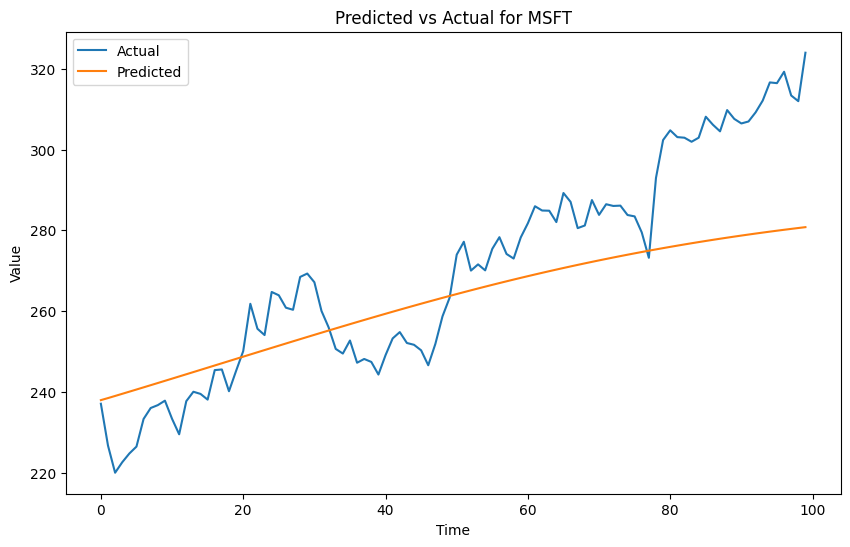

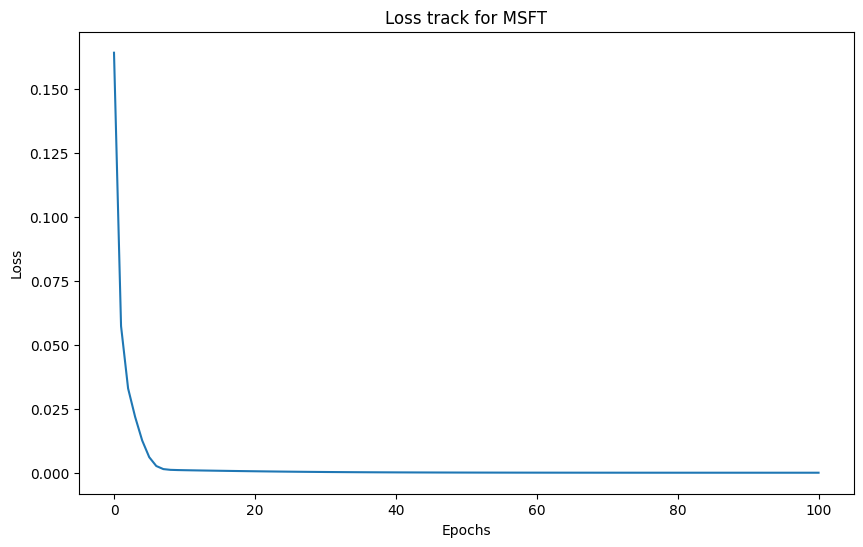

Evaluating model for ticker: MS
100


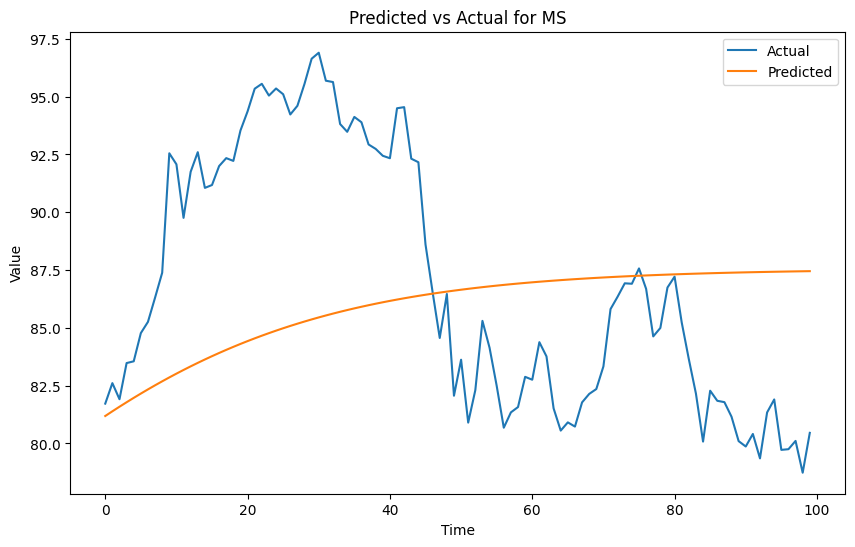

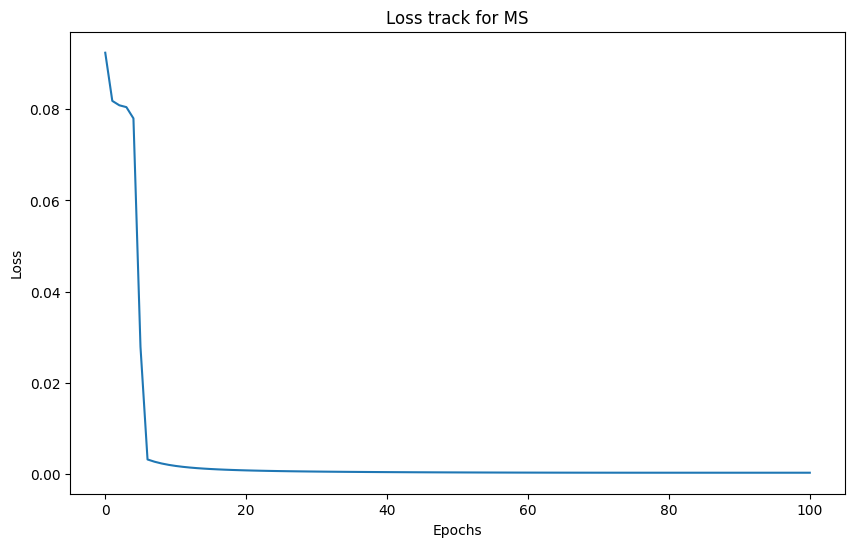

Evaluating model for ticker: NVDA
100


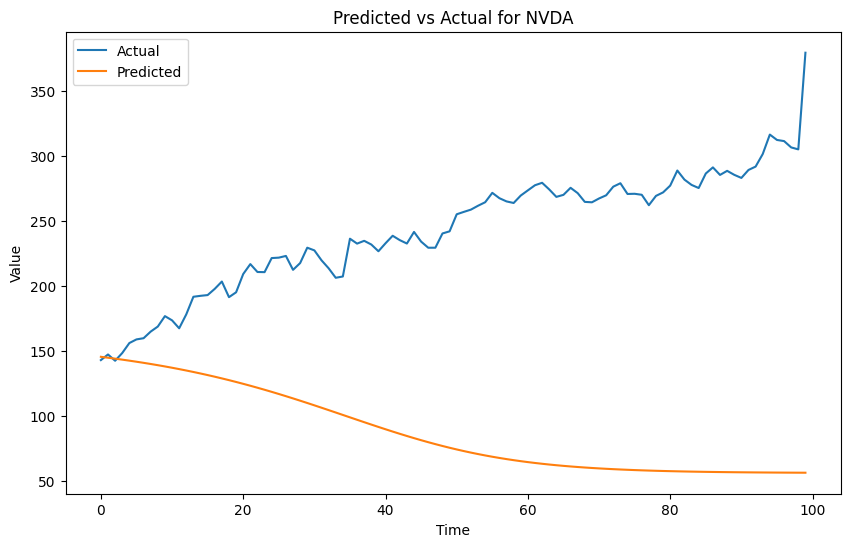

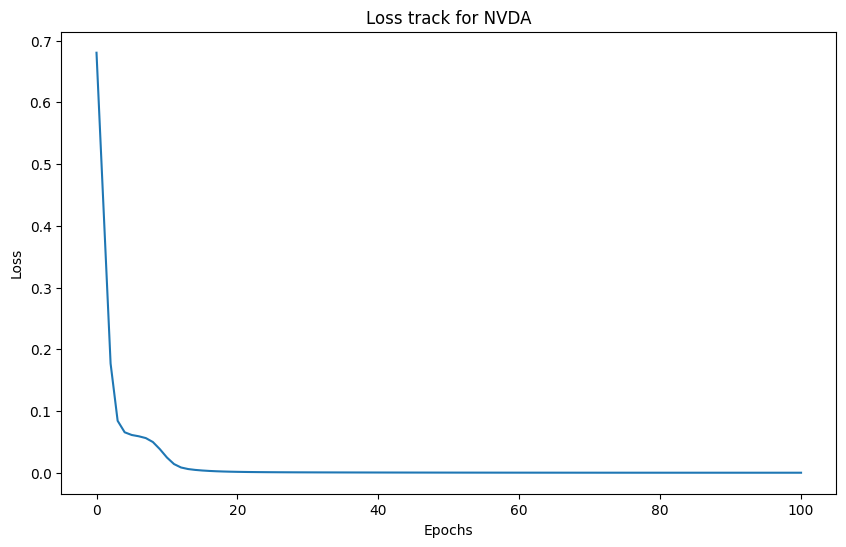

Evaluating model for ticker: TSLA
100


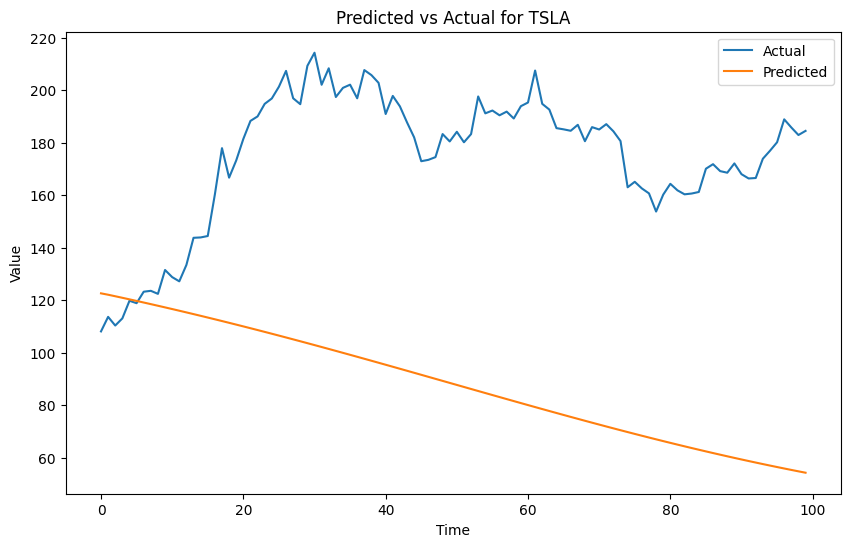

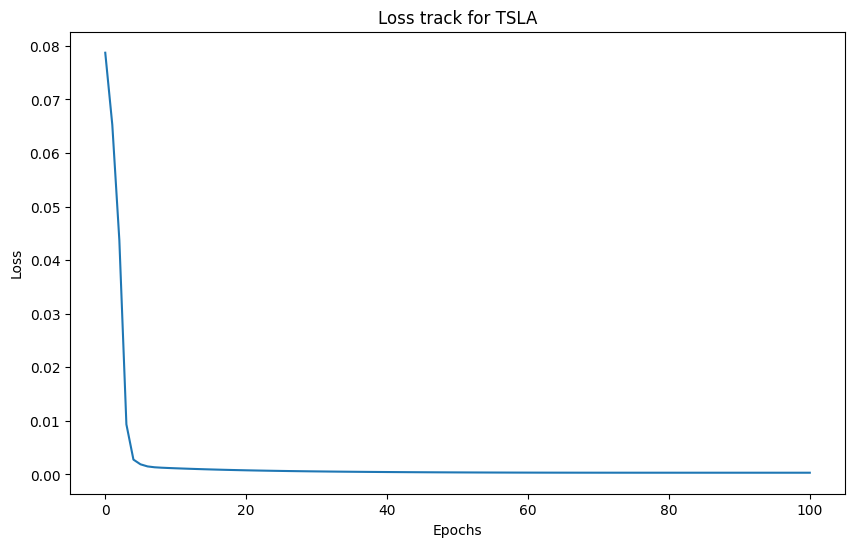

Evaluating model for ticker: VOO
100


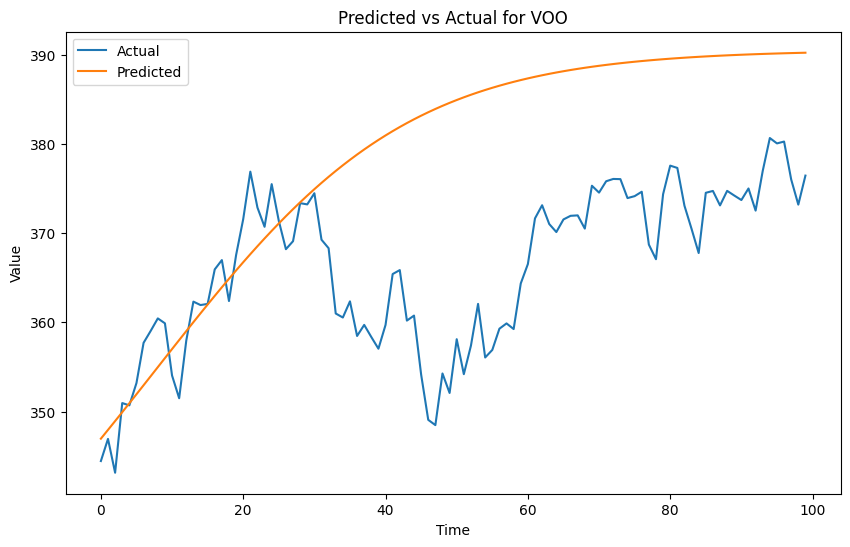

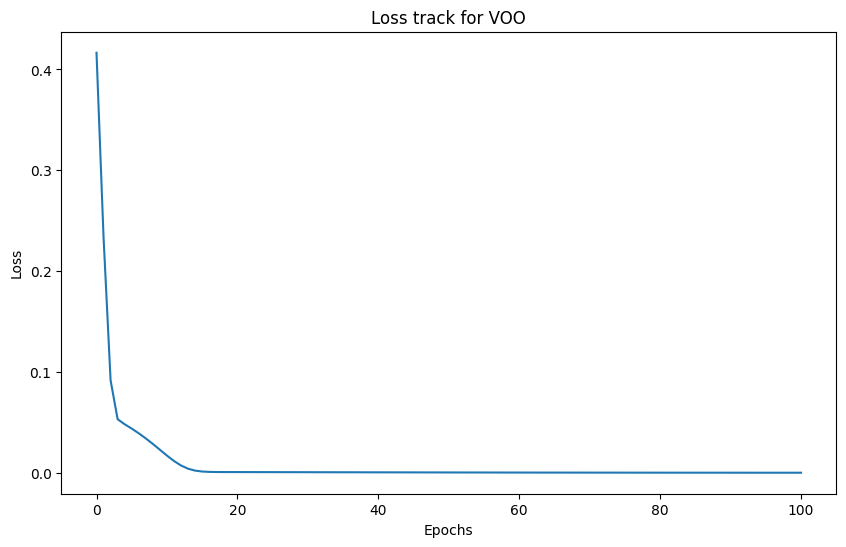

In [188]:
# Using the trained LSTM models to generate predictions on validation and test datasets, while also collecting model loss summaries.
# This step evaluates model performance out-of-sample and produces a forecasted dataframe along with corresponding loss metrics.
predicted_df, loss_df = MyLSTM.test(models, val_data, test_df, all_loss_tracks, scalars, seq_len)


In [189]:
# Optimizing portfolio weights using LSTM-generated forecasts to construct a neural-network-driven investment portfolio.
# This compares how deep-learning predictions translate into risk-optimized asset allocations relative to ARIMA and MPT.
nn_allocs = mpt.optimize_portfolio(predicted_df)
print("NN's Portfolio Allocation")
for val, ticker in zip(nn_allocs, l):
    print(ticker + ": " + str(round(val,3)))


NN's Portfolio Allocation
AAPL: 0.0
AMD: 0.006
AMZN: 0.0
F: 0.0
GOOG: 0.0
INTC: 0.799
JPM: 0.0
MSFT: 0.186
MS: 0.0
NVDA: 0.009
TSLA: 0.0
VOO: 0.0


In [190]:
# Evaluating the LSTM-based (neural network) portfolio using Sharpe, Treynor, Beta, and Alpha to measure risk-adjusted performance.
# This allows comparison of deep-learning-driven allocations against ARIMA, K-Means, and traditional MPT strategies.
mean_nn, std_nn, cr_nn, sr_nn = utils.sharpe_ratio_metrics(test_df, nn_allocs)
treynor_nn, beta_nn, alpha_nn = utils.treynor_ratio_metrics(
    test_df, nn_allocs, index_data
)
print("MyOptimizer Metrics")
print("Mean: " + str(mean_nn))
print("Std Dev: " + str(std_nn))
print("Cumulative Return: " + str(cr_nn))
print("Sharpe Ratio: " + str(sr_nn))
print("Treynor Ratio: " + str(treynor_nn))
print("Beta: " + str(beta_nn))
print("Alpha: " + str(alpha_nn))


MyOptimizer Metrics
Mean: 0.002316623447397822
Std Dev: 0.0152780781579525
Cumulative Return: 0.7287947414506353
Sharpe Ratio: 2.4070604142074252
Treynor Ratio: 0.001659476260978047
Beta: 1.2784897845705843
Alpha: 0.001057315581909691


In [191]:
# Evaluating the DBSCAN-derived portfolio by calculating key risk-adjusted performance measures including Sharpe, Treynor, Beta, and Alpha.
# This assessment shows how density-based clustering allocations compare against ARIMA, MPT, KMeans, and LSTM strategies.
dbscan_allocs = [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,0.5]
mean_dbscan, std_dbscan, cr_dbscan, sr_dbscan = utils.sharpe_ratio_metrics(test_df, dbscan_allocs)
treynor_dbscan, beta_dbscan, alpha_dbscan = utils.treynor_ratio_metrics(
    test_df, dbscan_allocs, index_data
)
print("MyOptimizer Metrics")
print("Mean: " + str(mean_dbscan))
print("Std Dev: " + str(std_dbscan))
print("Cumulative Return: " + str(cr_dbscan))
print("Sharpe Ratio: " + str(sr_dbscan))
print("Treynor Ratio: " + str(treynor_dbscan))
print("Beta: " + str(beta_dbscan))
print("Alpha: " + str(alpha_dbscan))


MyOptimizer Metrics
Mean: 0.0027407879184298445
Std Dev: 0.016598064395320144
Cumulative Return: 0.9116958581133567
Sharpe Ratio: 2.6213092282906105
Treynor Ratio: 0.0017632200549167133
Beta: 1.4438288127060213
Alpha: 0.001318621701536854
